<a href="https://colab.research.google.com/github/ednei-code/lunar-impact-simulator/blob/main/simulacao_lunar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Autor:** Ednei Vicente
**Profissão:** Cientista de Dados

# Simulador de Impactos Lunares Baseado em Dados Observacionais
## (Data-Driven Lunar Impact Simulator)

## Contexto

A superfície lunar é bombardeada continuamente por meteoroides, e esses impactos — muitos deles registrados como flashes óticos visíveis por frações de segundo — carregam informação estatística sobre a frequência, energia e distribuição espacial desses eventos. Diferente de uma simulação puramente visual, este projeto busca construir um simulador **orientado por dados reais**, capaz de aprender os padrões estatísticos de um conjunto de impactos observados e gerar eventos sintéticos consistentes com essas observações.

Neste projeto, utilizamos dados públicos do projeto **NELIOTA** (NEO Lunar Impacts and Optical Transients) 🔗 https://neliota.astro.noa.gr/, com o objetivo de caracterizar estatisticamente esses impactos e construir um gerador sintético capaz de reproduzir seu comportamento.

### O que é o NELIOTA e de onde vêm os dados

O NELIOTA é um projeto de monitoramento lunar financiado pela ESA, que tem como objetivo determinar a distribuição de tamanho e frequência de pequenos objetos próximos à Terra (NEOs) através da detecção de flashes de impacto na superfície da Lua.  O sistema opera no telescópio de 1,2 m de Kryoneri, do Observatório Nacional de Atenas, utilizando um instrumento de câmera dupla que realiza observações simultâneas em duas bandas fotométricas,  permitindo detectar e validar automaticamente flashes causados por micrometeoroides colidindo com a superfície lunar.

Os dados são coletados e disponibilizados publicamente pela própria equipe do NELIOTA: para cada evento validado são reportados data e hora, coordenadas de longitude e latitude lunares, e as magnitudes calibradas do flash nas bandas R e I.  Desde o início das observações em 2017, o projeto já acumulou centenas de horas de observação e detectou mais de 200 eventos de impacto lunar,  todos catalogados e acessíveis através do portal oficial do projeto.

## Objetivo Geral

Construir um modelo estatístico capaz de gerar impactos lunares sintéticos baseados em observações reais, aplicando técnicas de análise exploratória, modelagem probabilística e simulação computacional, e visualizar sua evolução temporal por meio de uma simulação científica.

## Pergunta Central

É possível caracterizar estatisticamente os padrões espaciais, temporais e energéticos dos impactos lunares observados pelo NELIOTA, construir um gerador sintético que preserve essas propriedades, simular sua evolução e explorar cenários hipotéticos de forma estatisticamente consistente?

### Análise Exploratória dos Dados

- Qual é a estrutura temporal e espacial do conjunto de impactos observados?
- Existem valores ausentes, inconsistentes ou outliers que precisam de tratamento?
- Como se distribuem as variáveis de magnitude e duração dos flashes?
- Existem padrões espaciais (concentração em determinadas regiões da superfície) ou temporais (sazonalidade, chuvas de meteoros) identificáveis?

### Modelagem Estatística

- Quais distribuições probabilísticas melhor descrevem as variáveis observadas (magnitude, duração, posição)?
- É possível estimar a densidade das variáveis via KDE de forma robusta?
- Um gerador baseado em amostragem/bootstrap reproduz fielmente as propriedades estatísticas do conjunto original?

### Geração Sintética e Simulação Temporal

- É possível gerar impactos sintéticos que preservem as distribuições e correlações observadas nos dados reais?
- Como representar a evolução temporal desses impactos em um sistema de simulação contínua?
- É possível visualizar essa evolução de forma científica (não apenas ilustrativa)?

### Validação e Cenários Hipotéticos

- Os dados simulados são estatisticamente indistinguíveis dos dados reais, segundo testes formais (Kolmogorov-Smirnov, Jensen-Shannon, entre outros)?
- Uma vez validado, o simulador se comporta de forma consistente sob condições alteradas (ex.: aumento da taxa de impactos, chuva de meteoros)?
- Quais são as principais limitações do modelo e do processo de geração sintética?

## Escopo do Projeto

Este projeto cobre o ciclo completo de **análise → modelagem → geração sintética → simulação → visualização → validação → exploração de cenários hipotéticos**. Extensões futuras — como física simplificada de crateras, modelos de IA (clusterização, redes neurais) e dashboards interativos 3D — ficam fora do escopo desta primeira versão e são discutidas ao final como possíveis trabalhos futuros.

In [ ]:
# ==========================================================
# Instalação das bibliotecas necessárias
# ==========================================================
!pip -q install opencv-python-headless

# ==========================================================
# Bibliotecas para manipulação de dados
# ==========================================================
import pandas as pd
import numpy as np

# ==========================================================
# Visualização
# ==========================================================
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# ==========================================================
# Datas
# ==========================================================
from datetime import datetime, timedelta

# ==========================================================
# Estatística e Modelagem Probabilística
# ==========================================================
from scipy import stats
from scipy.stats import gaussian_kde, ks_2samp, chi2_contingency, wasserstein_distance
from scipy.spatial.distance import jensenshannon

# ==========================================================
# Simulação (geração de eventos sintéticos)
# ==========================================================
import random

# ==========================================================
# Visualização científica / exportação em vídeo
# ==========================================================
import cv2

# ==========================================================
# Ignorar warnings desnecessários
# ==========================================================
import warnings
warnings.filterwarnings('ignore')

# ==========================================================
# Configurações visuais
# ==========================================================
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")
sns.set_context("notebook")
plt.rcParams['figure.figsize'] = (10, 6)

# ==========================================================
# Configurações gerais
# ==========================================================
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 6)
np.random.seed(42)  # reprodutibilidade das simulações

print("✅ Ambiente configurado com sucesso!")

✅ Ambiente configurado com sucesso!


In [ ]:
# ==========================================================
# Carregamento dos Dados
# ==========================================================
caminho = "/content/sample_data/impacto_lunar.csv"
df = pd.read_csv(caminho)

print(f"Total de registros: {len(df)}")
df.head()

Total de registros: 313


,UT Date,UT Time,R Magnitude,R Magnitude error,I Magnitude,I Magnitude error,Lunar Latitude (degrees),Lunar Latitude error (degrees),Lunar Longitude (degrees),Lunar Longitude error (degrees),Frames in R,Frames in I,Max Duration (sec),Airmass,Expert Classification
0,2017-02-01,17:13:57.863,10.15,0.12,9.05,0.05,-1.5,0.5,-29.2,0.5,1,1,0.033,1.66,NEO
1,2017-03-01,17:08:46.573,6.67,0.07,6.07,0.06,-10.3,0.5,-9.7,0.5,2,4,0.132,2.18,NEO
2,2017-03-01,17:13:17.36,9.15,0.11,8.23,0.07,4.5,0.5,29.9,0.5,1,1,0.033,2.18,NEO
3,2017-03-04,20:51:31.853,9.50,0.14,8.79,0.06,-12.7,0.5,-58.9,0.5,1,1,0.033,2.55,NEO
4,2017-04-01,19:45:51.65,10.18,0.13,8.61,0.03,11.6,0.5,-58.8,0.5,1,1,0.033,2.44,NEO


In [ ]:
# ==========================================================
# Renomeando as colunas para melhor manipulação
# ==========================================================
df = df.rename(columns={
    "UT Date": "ut_date",
    "UT Time": "ut_time",
    "R Magnitude": "r_mag",
    "R Magnitude error": "r_mag_error",
    "I Magnitude": "i_mag",
    "I Magnitude error": "i_mag_error",
    "Lunar Latitude (degrees)": "lunar_lat",
    "Lunar Latitude error (degrees)": "lunar_lat_error",
    "Lunar Longitude (degrees)": "lunar_lon",
    "Lunar Longitude error (degrees)": "lunar_lon_error",
    "Frames in R": "frames_r",
    "Frames in I": "frames_i",
    "Max Duration (sec)": "duration_sec",
    "Airmass": "airmass",
    "Expert Classification": "expert_class"
})

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 313 entries, 0 to 312
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ut_date          313 non-null    object 
 1   ut_time          313 non-null    object 
 2   r_mag            313 non-null    float64
 3   r_mag_error      313 non-null    float64
 4   i_mag            313 non-null    float64
 5   i_mag_error      313 non-null    float64
 6   lunar_lat        313 non-null    float64
 7   lunar_lat_error  313 non-null    float64
 8   lunar_lon        313 non-null    float64
 9   lunar_lon_error  313 non-null    float64
 10  frames_r         313 non-null    int64  
 11  frames_i         313 non-null    int64  
 12  duration_sec     313 non-null    float64
 13  airmass          313 non-null    float64
 14  expert_class     313 non-null    object 
dtypes: float64(10), int64(2), object(3)
memory usage: 36.8+ KB


In [ ]:
# ==========================================================
# Criar coluna datetime combinando data e hora
# ==========================================================
df["datetime"] = pd.to_datetime(df["ut_date"] + " " + df["ut_time"])
df["year"] = df["datetime"].dt.year
df["month"] = df["datetime"].dt.month

df[["ut_date", "ut_time", "datetime"]].head()

,ut_date,ut_time,datetime
0,2017-02-01,17:13:57.863,2017-02-01 17:13:57.863
1,2017-03-01,17:08:46.573,2017-03-01 17:08:46.573
2,2017-03-01,17:13:17.36,2017-03-01 17:13:17.360
3,2017-03-04,20:51:31.853,2017-03-04 20:51:31.853
4,2017-04-01,19:45:51.65,2017-04-01 19:45:51.650


### Limpeza da Magnitude R

A inspeção do dataset revelou que o valor `-99.99` aparece em diversos registros de `r_mag`. Esse valor não é fisicamente possível para magnitudes fotométricas — é usado pelo pipeline do NELIOTA como placeholder para ausência de detecção no filtro R. Convertendo para `NaN` para evitar distorções estatísticas nas análises seguintes.

In [ ]:
# ==========================================================
# Limpeza da coluna de magnitude R (placeholder -99.99)
# ==========================================================
print("Registros com r_mag < 0:", (df["r_mag"] < 0).sum())

df["r_mag"] = df["r_mag"].mask(df["r_mag"] < 0, np.nan)

print("Registros com r_mag < 0 após correção:", (df["r_mag"] < 0).sum())

Registros com r_mag < 0: 101
Registros com r_mag < 0 após correção: 0


### Padronização da Classificação dos Especialistas

A coluna `expert_class` apresenta mais de 30 variações de rótulo (diferenças de capitalização, grafia e semântica). Agrupamos os eventos em três classes principais — `real`, `neo` e `suspected` — para permitir o filtro de confiabilidade na próxima etapa.

In [ ]:
# ==========================================================
# Padronização da coluna-alvo (expert_class)
# ==========================================================
# A coluna original apresenta grande variação de rótulos
# (diferenças de capitalização, variações semânticas, erros
# de grafia). Agrupamos em três classes principais + resíduo.
df["expert_class"] = df["expert_class"].str.lower().str.strip()

def padronizar_classificacao(x):
    if any(palavra in x for palavra in ["real", "validated", "true impact", "impact flash"]):
        return "real"
    if "neo" in x:
        return "neo"
    if "suspected" in x:
        return "suspected"
    return "other"

df["expert_class_clean"] = df["expert_class"].apply(padronizar_classificacao)

print("Distribuição das classes padronizadas:")
print(df["expert_class_clean"].value_counts())

Distribuição das classes padronizadas:
expert_class_clean
real         219
neo           76
suspected     16
other          2
Name: count, dtype: int64


### Filtro de Confiabilidade — Base para o Gerador Sintético

O gerador sintético deve aprender apenas com eventos confirmados, evitando que ruído estatístico de falsos-positivos contamine as distribuições. Por isso, mantemos somente as classes `real` e `neo`, descartando `suspected` e `other` (baixa confiabilidade, conforme já demonstrado no projeto anterior de classificação).

In [ ]:
# ==========================================================
# Filtro: manter apenas eventos confiáveis (real + neo)
# ==========================================================
# 'suspected' e 'other' são eventos de baixa confiabilidade e
# não devem contaminar as distribuições que o gerador sintético
# vai aprender.
df_confirmados = df[df["expert_class_clean"].isin(["real", "neo"])].copy()

print(f"Total de eventos originais: {len(df)}")
print(f"Total de eventos confirmados (real + neo): {len(df_confirmados)}")
print(f"\nDistribuição:")
print(df_confirmados["expert_class_clean"].value_counts())

Total de eventos originais: 313
Total de eventos confirmados (real + neo): 295

Distribuição:
expert_class_clean
real    219
neo      76
Name: count, dtype: int64


### Verificação de Integridade — Base Confirmada

Antes de iniciar a Análise Exploratória (EDA), verificamos a integridade de `df_confirmados`: valores ausentes, duplicatas e um resumo estatístico inicial das variáveis físicas que vão alimentar o gerador sintético (`i_mag`, `duration_sec`, `lunar_lat`, `lunar_lon`).

In [ ]:
# ==========================================================
# Verificação de valores ausentes e duplicatas
# ==========================================================
print("Valores ausentes por coluna:")
print(df_confirmados.isna().sum())

print("\nLinhas duplicadas:", df_confirmados.duplicated().sum())

print("\nResumo estatístico das variáveis físicas:")
df_confirmados[["i_mag", "r_mag", "duration_sec", "lunar_lat", "lunar_lon", "airmass"]].describe()

Valores ausentes por coluna:
ut_date                0
ut_time                0
r_mag                 89
r_mag_error            0
i_mag                  0
i_mag_error            0
lunar_lat              0
lunar_lat_error        0
lunar_lon              0
lunar_lon_error        0
frames_r               0
frames_i               0
duration_sec           0
airmass                0
expert_class           0
datetime               0
year                   0
month                  0
expert_class_clean     0
dtype: int64

Linhas duplicadas: 0

Resumo estatístico das variáveis físicas:


,i_mag,r_mag,duration_sec,lunar_lat,lunar_lon,airmass
count,295.000000,206.000000,295.000000,295.000000,295.000000,295.000000
mean,8.983627,9.811796,0.062915,1.805085,-0.006102,2.249383
std,0.991763,0.929102,0.049279,20.236275,51.890366,0.661600
min,5.490000,6.650000,0.033000,-41.000000,-93.300000,1.081000
25%,8.495000,9.242500,0.033000,-12.250000,-44.900000,1.717500
50%,9.180000,9.965000,0.066000,2.200000,-12.300000,2.240000
75%,9.635000,10.440000,0.066000,16.900000,51.050000,2.674000
max,11.620000,11.940000,0.429000,71.600000,89.100000,3.823000


### Conclusão (Passo 1) — Carregamento e Limpeza dos Dados

**Em resumo:** carregamos os 313 eventos registrados pelo NELIOTA, organizamos as datas, corrigimos um valor "fantasma" que aparecia na magnitude do filtro R, e padronizamos os rótulos dados pelos especialistas. No final, ficamos só com os eventos confiáveis (impactos confirmados como reais ou como NEOs) — 295 no total — que servirão de base para o simulador aprender os padrões estatísticos dos impactos lunares.

**Em termos técnicos:** o dataset original (313 registros, 15 colunas) foi renomeado para nomenclatura padronizada em `snake_case`, e as colunas `ut_date`/`ut_time` foram combinadas em uma variável `datetime`. O placeholder não-físico `-99.99` presente em `r_mag` (101 registros no dataset completo) foi convertido para `NaN`. A coluna `Expert Classification`, com mais de 30 variações de rótulo, foi padronizada em `expert_class_clean` (real/neo/suspected/other), e o dataset foi filtrado para reter apenas as classes `real` e `neo` — resultando em `df_confirmados` com **295 eventos**, 0 duplicatas e sem valores ausentes nas variáveis físicas centrais (`i_mag`, `duration_sec`, `lunar_lat`, `lunar_lon`), com exceção de `r_mag` (206/295 válidos, 89 ausentes), que será tratada como variável secundária. Essa base servirá de fundação estatística para a modelagem probabilística (Passo 2) e o gerador sintético (Passo 3).

## Passo 2 — Análise Exploratória (EDA) Visual

Com a base de 295 eventos confirmados (`df_confirmados`) já limpa e íntegra, exploramos visualmente as distribuições das variáveis que servirão de base para o gerador sintético: brilho (`i_mag`), duração (`duration_sec`), e a distribuição espacial (`lunar_lat`/`lunar_lon`) e temporal dos impactos.

O objetivo aqui é identificar a forma dessas distribuições (normal, assimétrica, multimodal etc.), o que vai guiar a escolha das técnicas de modelagem estatística no Passo 3.

### Distribuição de Brilho e Duração dos Flashes

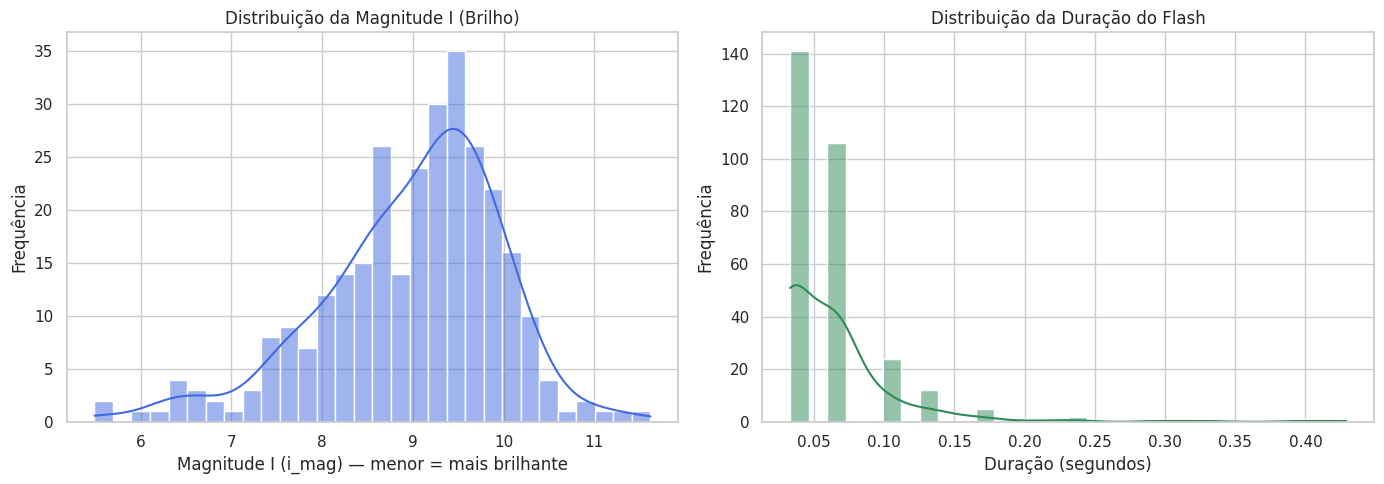

Assimetria (skew) — i_mag: -0.7721
Assimetria (skew) — duration_sec: 3.9064


In [ ]:
# ==========================================================
# Distribuição da Magnitude I (brilho) e da Duração
# ==========================================================
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_confirmados["i_mag"], bins=30, kde=True, color="royalblue", ax=axs[0])
axs[0].set_title("Distribuição da Magnitude I (Brilho)")
axs[0].set_xlabel("Magnitude I (i_mag) — menor = mais brilhante")
axs[0].set_ylabel("Frequência")

sns.histplot(df_confirmados["duration_sec"], bins=30, kde=True, color="seagreen", ax=axs[1])
axs[1].set_title("Distribuição da Duração do Flash")
axs[1].set_xlabel("Duração (segundos)")
axs[1].set_ylabel("Frequência")

plt.tight_layout()
plt.show()

print(f"Assimetria (skew) — i_mag: {df_confirmados['i_mag'].skew():.4f}")
print(f"Assimetria (skew) — duration_sec: {df_confirmados['duration_sec'].skew():.4f}")

### Conclusão — Brilho e Duração

**Em resumo:** o brilho dos flashes segue um padrão parecido com um sino (a maioria tem brilho "médio", com poucos eventos muito brilhantes ou muito fracos). Já a duração é bem diferente: a maioria dos flashes é rapidíssima, e só alguns raros duram bem mais — como um "sprint" quase sempre curto, com corredores excepcionais de vez em quando.

**Em termos técnicos:** `i_mag` apresenta distribuição aproximadamente unimodal com leve assimetria negativa (skew ≈ -0.77), compatível com uma distribuição normal ou levemente assimétrica — uma distribuição paramétrica (normal ou skew-normal) ou KDE deve capturá-la bem no Passo 3. Já `duration_sec` apresenta assimetria positiva forte (skew ≈ 3.91), com concentração de massa em valores baixos (0.033–0.066s, provavelmente ligados à cadência discreta de amostragem das câmeras do NELIOTA) e uma cauda longa de eventos raros e mais duradouros — um comportamento típico de distribuições log-normal ou gama, que serão testadas na modelagem estatística.

### Distribuição Espacial dos Impactos na Superfície Lunar

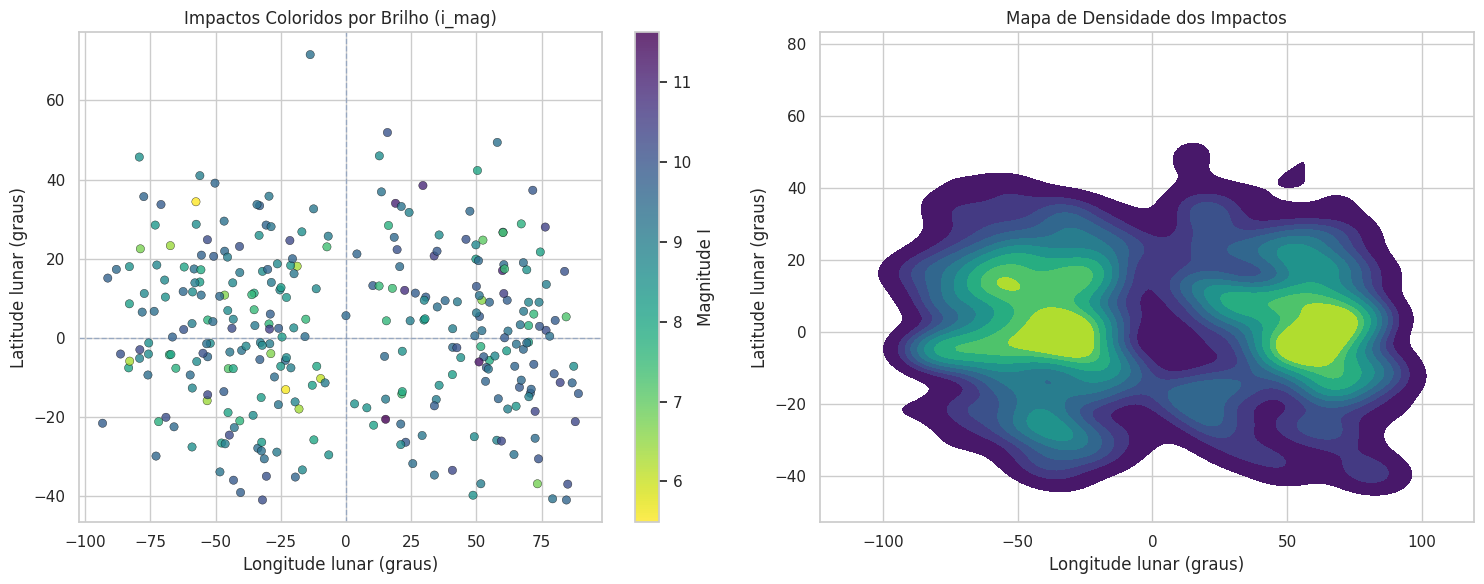

Latitude  — média: 1.81°, desvio: 20.24°
Longitude — média: -0.01°, desvio: 51.89°


In [ ]:
# ==========================================================
# Distribuição Espacial (Latitude x Longitude)
# ==========================================================
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

# Dispersão colorida por brilho
scatter = axs[0].scatter(
    df_confirmados["lunar_lon"],
    df_confirmados["lunar_lat"],
    c=df_confirmados["i_mag"],
    cmap="viridis_r",
    alpha=0.8,
    edgecolor="black",
    linewidth=0.3
)
axs[0].axhline(0, linestyle="--", linewidth=1, alpha=0.4)
axs[0].axvline(0, linestyle="--", linewidth=1, alpha=0.4)
axs[0].set_title("Impactos Coloridos por Brilho (i_mag)")
axs[0].set_xlabel("Longitude lunar (graus)")
axs[0].set_ylabel("Latitude lunar (graus)")
plt.colorbar(scatter, ax=axs[0], label="Magnitude I")

# Mapa de densidade (KDE 2D)
sns.kdeplot(
    x=df_confirmados["lunar_lon"],
    y=df_confirmados["lunar_lat"],
    cmap="viridis",
    fill=True,
    bw_adjust=0.5,
    thresh=0.05,
    ax=axs[1]
)
axs[1].set_title("Mapa de Densidade dos Impactos")
axs[1].set_xlabel("Longitude lunar (graus)")
axs[1].set_ylabel("Latitude lunar (graus)")

plt.tight_layout()
plt.show()

# Testes de uniformidade espacial (correlação com brilho, já feito antes,
# aqui olhamos a dispersão pura)
print(f"Latitude  — média: {df_confirmados['lunar_lat'].mean():.2f}°, desvio: {df_confirmados['lunar_lat'].std():.2f}°")
print(f"Longitude — média: {df_confirmados['lunar_lon'].mean():.2f}°, desvio: {df_confirmados['lunar_lon'].std():.2f}°")

### Conclusão — Distribuição Espacial

**Em resumo:** os impactos aparecem espalhados por toda a face visível da Lua, sem se concentrar perto de nenhum polo — mas o mapa de "calor" revela duas regiões com mais eventos registrados, e uma faixa central com menos. Isso provavelmente não é porque a Lua "recebe" mais impactos ali — é mais provável que seja um efeito de como e onde o telescópio aponta suas observações.

**Em termos técnicos:** a latitude (média ≈ 1.8°, desvio ≈ 20.2°) e a longitude (média ≈ -0.01°, desvio ≈ 51.9°) estão centradas próximas de zero, sem viés hemisférico aparente — resultado consistente com um bombardeamento isotrópico de micrometeoroides, como já documentado no projeto de classificação anterior. Entretanto, o mapa de densidade KDE revela dois núcleos de maior concentração (próximos a lon ≈ -50° e lon ≈ +65°) e uma região de menor densidade perto de lon ≈ 0°. Esse padrão bimodal é mais provavelmente um artefato observacional — ligado à geometria do campo de visão do telescópio de Kryoneri e/ou aos pontings específicos usados na campanha NELIOTA — do que um fenômeno físico real. Essa observação será registrada como limitação e vai orientar a escolha do modelo espacial no Passo 3: preferimos uma técnica (como KDE 2D com ajuste apropriado, ou até um modelo uniforme) que respeite esse padrão observado nos dados reais, mesmo sem assumir causa física para ele.

### Distribuição Temporal dos Impactos

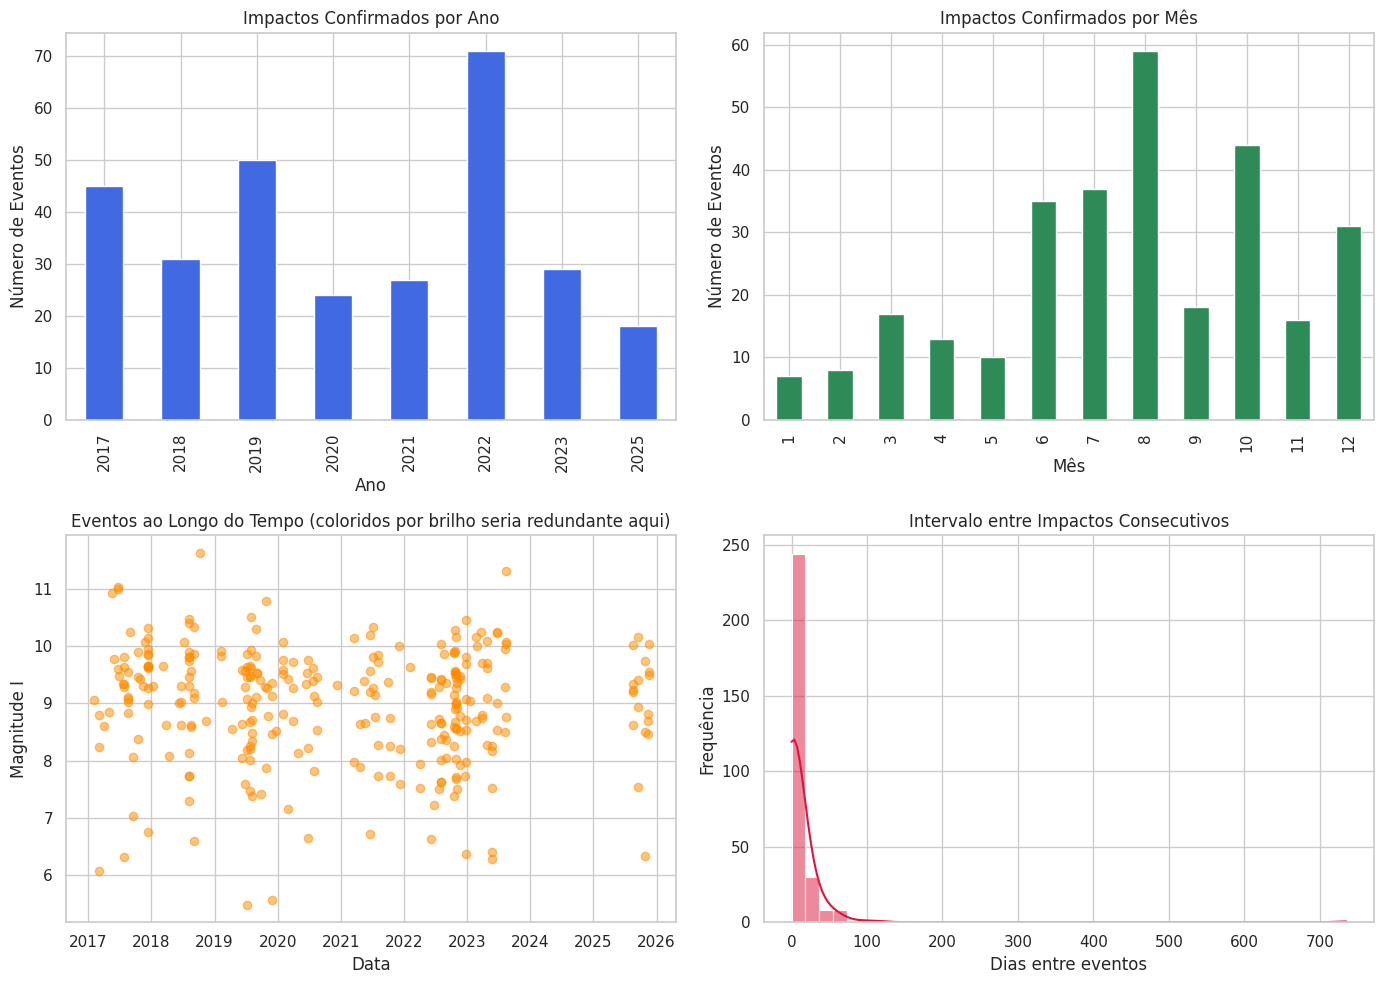

Intervalo médio entre impactos: 10.92 dias
Intervalo mediano entre impactos: 0.89 dias
Assimetria (skew) do intervalo: 13.9243


In [ ]:
# ==========================================================
# Distribuição Temporal — Impactos por Ano, Mês e Intervalo entre Eventos
# ==========================================================
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# 1) Impactos por ano
df_confirmados["year"].value_counts().sort_index().plot(kind="bar", ax=axs[0, 0], color="royalblue")
axs[0, 0].set_title("Impactos Confirmados por Ano")
axs[0, 0].set_xlabel("Ano")
axs[0, 0].set_ylabel("Número de Eventos")

# 2) Impactos por mês (sazonalidade)
df_confirmados["month"].value_counts().sort_index().plot(kind="bar", ax=axs[0, 1], color="seagreen")
axs[0, 1].set_title("Impactos Confirmados por Mês")
axs[0, 1].set_xlabel("Mês")
axs[0, 1].set_ylabel("Número de Eventos")

# 3) Linha do tempo (dispersão ao longo dos anos)
axs[1, 0].scatter(df_confirmados["datetime"], df_confirmados["i_mag"], alpha=0.5, color="darkorange")
axs[1, 0].set_title("Eventos ao Longo do Tempo (coloridos por brilho seria redundante aqui)")
axs[1, 0].set_xlabel("Data")
axs[1, 0].set_ylabel("Magnitude I")

# 4) Intervalo entre impactos consecutivos (dias) — fundamental para a simulação temporal
df_sorted = df_confirmados.sort_values("datetime").reset_index(drop=True)
intervalos_dias = df_sorted["datetime"].diff().dt.total_seconds() / 86400
intervalos_dias = intervalos_dias.dropna()

sns.histplot(intervalos_dias, bins=40, kde=True, color="crimson", ax=axs[1, 1])
axs[1, 1].set_title("Intervalo entre Impactos Consecutivos")
axs[1, 1].set_xlabel("Dias entre eventos")
axs[1, 1].set_ylabel("Frequência")

plt.tight_layout()
plt.show()

print(f"Intervalo médio entre impactos: {intervalos_dias.mean():.2f} dias")
print(f"Intervalo mediano entre impactos: {intervalos_dias.median():.2f} dias")
print(f"Assimetria (skew) do intervalo: {intervalos_dias.skew():.4f}")

### Conclusão — Distribuição Temporal

**Em resumo:** os impactos não "chegam" em um ritmo constante e uniforme — eles aparecem em rajadas, sempre que o telescópio está observando, com longos silêncios entre campanhas (incluindo um hiato completo em 2024, sem nenhum evento registrado). Isso é mais um reflexo de quando o sistema estava "de olho no céu" do que da frequência real de impactos na Lua.

**Em termos técnicos:** o intervalo entre eventos consecutivos apresenta forte discrepância entre mediana (0.89 dias) e média (10.92 dias), com assimetria extrema (skew ≈ 13.92) — sintoma de outliers pronunciados na cauda direita. A ausência total de eventos em 2024 (visível no gráfico de contagem anual) produz um hiato de observação de várias centenas de dias, que distorce a média do intervalo. Esse padrão confirma o que já havia sido identificado no projeto de classificação anterior: a variação de detecções está associada a condições operacionais (disponibilidade do telescópio, sazonalidade de noites observáveis — pico em jun/jul/ago/out) e não a uma taxa física constante de impactos lunares.

**Implicação para o Passo 4 (Simulação Temporal):** um processo de Poisson homogêneo simples (taxa constante) não representaria fielmente esse comportamento. Duas abordagens serão consideradas: (1) modelar apenas a taxa de impactos *durante* períodos ativos de observação (ignorando os hiatos como não-informativos), tratando-os como um processo de Poisson condicional; ou (2) usar diretamente a distribuição empírica dos intervalos (via bootstrap/KDE) para preservar o padrão de rajadas observado nos dados reais. Essa decisão será formalizada no Passo 3.

## Passo 3 — Modelagem Estatística

Com os padrões das variáveis já mapeados no Passo 2, construímos aqui os modelos probabilísticos que servirão de base para o gerador sintético (Passo 4). Cada variável recebe a técnica mais adequada ao seu comportamento observado:

- **Brilho (`i_mag`)** — aproximadamente normal (skew ≈ -0.77) → testamos normal, skew-normal e KDE
- **Duração (`duration_sec`)** — fortemente assimétrica (skew ≈ 3.91) → testamos log-normal, gama e KDE
- **Posição espacial (`lunar_lat`/`lunar_lon`)** — KDE 2D (já validado visualmente no Passo 2)
- **Taxa temporal de impactos** — processo de Poisson não-homogêneo, com `λ(t)` variando por mês (sazonalidade)

O objetivo é escolher, para cada variável, o modelo que melhor reproduz a distribuição real — validado via ajuste visual e testes de aderência (Kolmogorov-Smirnov).

### Modelagem do Brilho (i_mag)

Testamos três abordagens para `i_mag`: distribuição normal, skew-normal (captura a leve assimetria observada) e KDE (não-paramétrica, mais flexível). Comparamos visualmente e via teste de Kolmogorov-Smirnov qual se ajusta melhor aos dados reais.

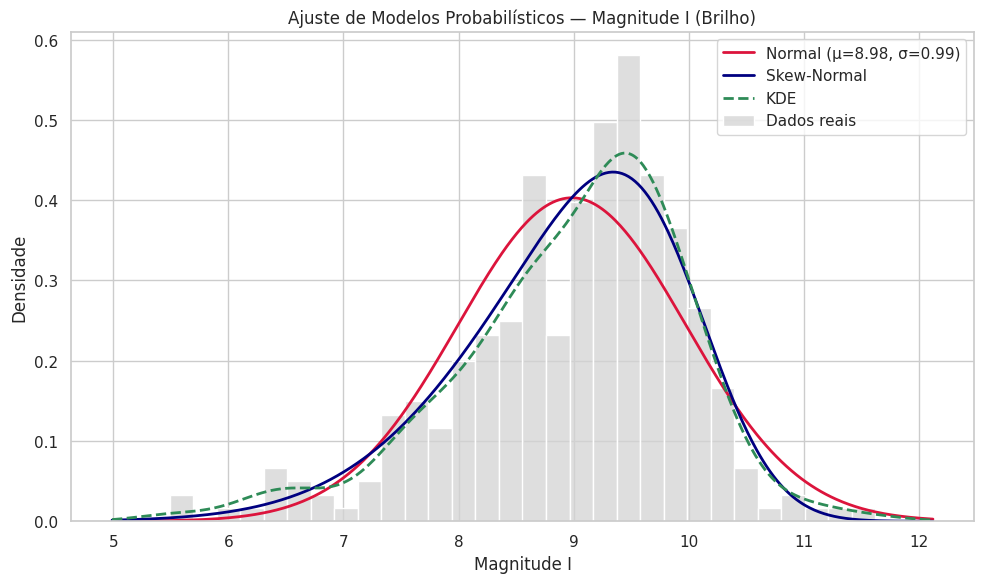

KS Test — Normal:      estatística=0.0913, p-valor=0.0137
KS Test — Skew-Normal: estatística=0.0558, p-valor=0.3067


In [ ]:
# ==========================================================
# Modelagem Estatística — Brilho (i_mag)
# ==========================================================
from scipy.stats import norm, skewnorm, kstest, gaussian_kde

dados_imag = df_confirmados["i_mag"].values

# --- Ajuste dos modelos ---
# 1) Normal
mu, sigma = norm.fit(dados_imag)

# 2) Skew-normal
a_skew, loc_skew, scale_skew = skewnorm.fit(dados_imag)

# 3) KDE (não-paramétrico)
kde_imag = gaussian_kde(dados_imag)

# --- Grade para plotar as curvas ajustadas ---
x_grid = np.linspace(dados_imag.min() - 0.5, dados_imag.max() + 0.5, 500)

plt.figure(figsize=(10, 6))
sns.histplot(dados_imag, bins=30, stat="density", color="lightgray", label="Dados reais")
plt.plot(x_grid, norm.pdf(x_grid, mu, sigma), color="crimson", lw=2, label=f"Normal (μ={mu:.2f}, σ={sigma:.2f})")
plt.plot(x_grid, skewnorm.pdf(x_grid, a_skew, loc_skew, scale_skew), color="navy", lw=2, label="Skew-Normal")
plt.plot(x_grid, kde_imag(x_grid), color="seagreen", lw=2, linestyle="--", label="KDE")
plt.title("Ajuste de Modelos Probabilísticos — Magnitude I (Brilho)")
plt.xlabel("Magnitude I")
plt.ylabel("Densidade")
plt.legend()
plt.tight_layout()
plt.show()

# --- Teste de aderência (Kolmogorov-Smirnov) ---
ks_normal = kstest(dados_imag, "norm", args=(mu, sigma))
ks_skewnorm = kstest(dados_imag, "skewnorm", args=(a_skew, loc_skew, scale_skew))

print(f"KS Test — Normal:      estatística={ks_normal.statistic:.4f}, p-valor={ks_normal.pvalue:.4f}")
print(f"KS Test — Skew-Normal: estatística={ks_skewnorm.statistic:.4f}, p-valor={ks_skewnorm.pvalue:.4f}")

### Conclusão — Modelagem do Brilho (i_mag)

**Em resumo:** testamos três formas de descrever matematicamente o brilho dos flashes, e a que melhor capturou o formato real dos dados foi a "curva de sino" com uma leve inclinação (skew-normal) — ela reconhece que existem um pouco mais de eventos muito brilhantes do que uma curva perfeitamente simétrica preveria.

**Em termos técnicos:** o teste de Kolmogorov-Smirnov rejeita a hipótese de normalidade pura (estatística = 0.0913, p = 0.0137 < 0.05), mas não rejeita o ajuste skew-normal (estatística = 0.0558, p = 0.3067 > 0.05) — confirmando estatisticamente a assimetria negativa já identificada no Passo 2 (skew ≈ -0.77). A curva skew-normal também acompanha de perto o KDE não-paramétrico, reforçando a robustez do ajuste. **A distribuição skew-normal será adotada no gerador sintético para amostrar `i_mag`.**

### Modelagem da Duração do Flash (duration_sec)

A duração apresentou forte assimetria positiva no Passo 2. Testamos distribuição log-normal e gama — ambas adequadas para variáveis estritamente positivas com cauda longa — além do KDE como referência não-paramétrica.

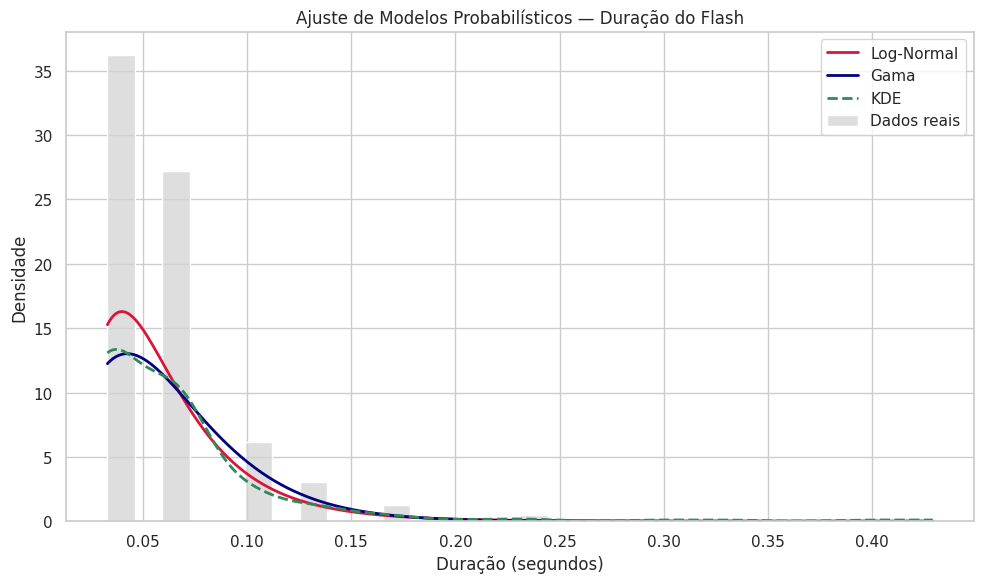

KS Test — Log-Normal: estatística=0.2917, p-valor=0.0000
KS Test — Gama:       estatística=0.2729, p-valor=0.0000


In [ ]:
# ==========================================================
# Modelagem Estatística — Duração do Flash (duration_sec)
# ==========================================================
from scipy.stats import lognorm, gamma

dados_duracao = df_confirmados["duration_sec"].values

# --- Ajuste dos modelos ---
shape_ln, loc_ln, scale_ln = lognorm.fit(dados_duracao, floc=0)
shape_gamma, loc_gamma, scale_gamma = gamma.fit(dados_duracao, floc=0)
kde_duracao = gaussian_kde(dados_duracao)

# --- Grade para plotar ---
x_grid_dur = np.linspace(dados_duracao.min(), dados_duracao.max(), 500)

plt.figure(figsize=(10, 6))
sns.histplot(dados_duracao, bins=30, stat="density", color="lightgray", label="Dados reais")
plt.plot(x_grid_dur, lognorm.pdf(x_grid_dur, shape_ln, loc_ln, scale_ln), color="crimson", lw=2, label="Log-Normal")
plt.plot(x_grid_dur, gamma.pdf(x_grid_dur, shape_gamma, loc_gamma, scale_gamma), color="navy", lw=2, label="Gama")
plt.plot(x_grid_dur, kde_duracao(x_grid_dur), color="seagreen", lw=2, linestyle="--", label="KDE")
plt.title("Ajuste de Modelos Probabilísticos — Duração do Flash")
plt.xlabel("Duração (segundos)")
plt.ylabel("Densidade")
plt.legend()
plt.tight_layout()
plt.show()

# --- Teste de aderência (Kolmogorov-Smirnov) ---
ks_lognorm = kstest(dados_duracao, "lognorm", args=(shape_ln, loc_ln, scale_ln))
ks_gamma = kstest(dados_duracao, "gamma", args=(shape_gamma, loc_gamma, scale_gamma))

print(f"KS Test — Log-Normal: estatística={ks_lognorm.statistic:.4f}, p-valor={ks_lognorm.pvalue:.4f}")
print(f"KS Test — Gama:       estatística={ks_gamma.statistic:.4f}, p-valor={ks_gamma.pvalue:.4f}")

### Investigação — Duração é uma Variável Discreta?

Os testes de Kolmogorov-Smirnov rejeitaram fortemente tanto log-normal quanto gama (p ≈ 0.0000 para ambos). O histograma sugere que `duration_sec` não é contínua, mas quantizada em múltiplos de um valor fixo — provavelmente ligado à cadência de captura das câmeras (30 fps ≈ 0.033s por frame). Verificamos os valores únicos para confirmar.

In [ ]:
# ==========================================================
# Verificação de discretização em duration_sec
# ==========================================================
valores_unicos = np.sort(df_confirmados["duration_sec"].unique())
print(f"Número de valores únicos: {len(valores_unicos)}")
print(f"Valores únicos: {valores_unicos}")

# Verificar se são múltiplos aproximados de 0.033s (cadência de 1 frame a 30fps)
razao = valores_unicos / 0.033
print(f"\nRazão em relação a 0.033s (cadência de 1 frame): {np.round(razao, 2)}")

Número de valores únicos: 14
Valores únicos: [0.033 0.066 0.067 0.099 0.1   0.132 0.133 0.165 0.198 0.231 0.297 0.33
 0.396 0.429]

Razão em relação a 0.033s (cadência de 1 frame): [ 1.    2.    2.03  3.    3.03  4.    4.03  5.    6.    7.    9.   10.
 12.   13.  ]


### Conclusão — Duração é Discreta, não Contínua

**Em resumo:** confirmamos que a duração do flash não é um número "livre" — ela só pode assumir valores múltiplos do tempo entre um frame e outro da câmera (cada frame dura cerca de 0.033 segundos). Ou seja, a câmera não consegue medir durações fracionadas de frame, só duração = 1 frame, 2 frames, 3 frames, etc. Isso explica por que nenhuma curva "lisa" (log-normal, gama) conseguiu se ajustar bem: os dados reais são degraus, não uma curva suave.

**Em termos técnicos:** os 295 eventos confirmados assumem apenas 14 valores únicos de `duration_sec`, todos consistentes com múltiplos inteiros de ≈0.033s (razão variando de 1.00 a 13.00, com desvios residuais de até 3% atribuíveis a arredondamento na captura) — ou seja, `duration_sec ≈ n_frames × cadência`, com `n_frames` variando de 1 a 13. Isso invalida o uso de distribuições contínuas (log-normal, gama) como modelo gerador direto, já que elas atribuiriam probabilidade positiva a durações fisicamente impossíveis para o instrumento (ex: 0.05s).

**Abordagem adotada:** modelaremos `n_frames` (não `duration_sec` diretamente) como uma variável discreta, ajustando uma distribuição geométrica ou binomial negativa sobre a contagem de frames (ambas adequadas para contagens positivas com cauda longa), ou alternativamente amostrando diretamente da distribuição empírica de frequências observada. A duração sintética final será então reconstruída como `n_frames_sintético × 0.033`, preservando a granularidade física real do instrumento.

### Modelagem de n_frames (Duração como Contagem Discreta)

Convertendo `duration_sec` para número de frames (`duration_sec / 0.033`, arredondado), testamos a distribuição empírica de frequências e uma distribuição geométrica ajustada, mais apropriada para essa variável de contagem.

Distribuição empírica de n_frames (duração):
n_frames_duracao
1     141
2     106
3      24
4      12
5       5
6       1
7       2
9       1
10      1
12      1
13      1
Name: count, dtype: int64

Média: 1.91
Mediana: 2.00


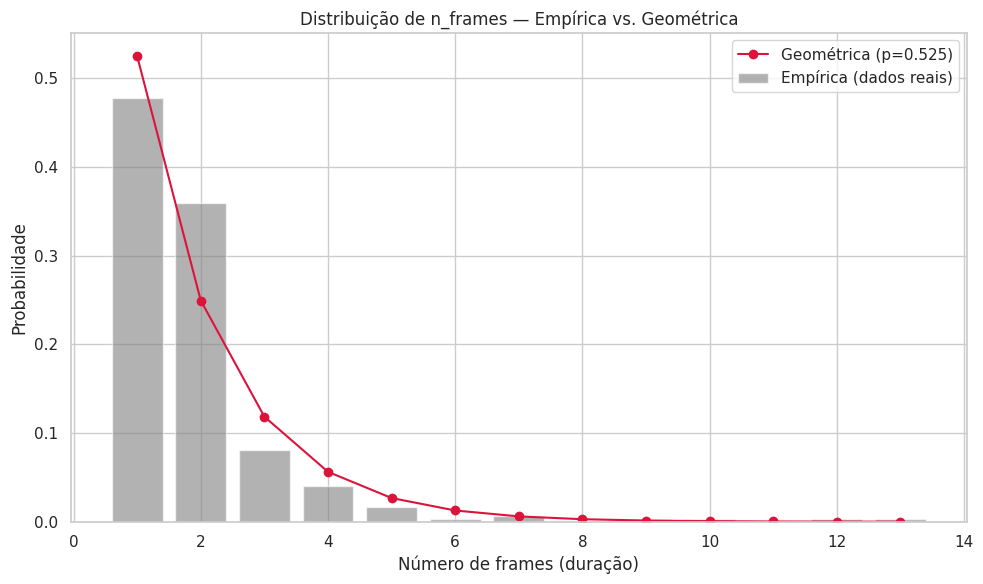


KS Test — Geométrica: estatística=0.5249, p-valor=0.0000


In [ ]:
# ==========================================================
# Modelagem de n_frames (duração como variável discreta)
# ==========================================================
from scipy.stats import geom, nbinom

CADENCIA = 0.033  # segundos por frame

df_confirmados["n_frames_duracao"] = np.round(df_confirmados["duration_sec"] / CADENCIA).astype(int)

# --- Distribuição empírica observada ---
freq_frames = df_confirmados["n_frames_duracao"].value_counts().sort_index()
print("Distribuição empírica de n_frames (duração):")
print(freq_frames)
print(f"\nMédia: {df_confirmados['n_frames_duracao'].mean():.2f}")
print(f"Mediana: {df_confirmados['n_frames_duracao'].median():.2f}")

# --- Ajuste de distribuição geométrica (contagens positivas, decaimento) ---
p_geom = 1 / df_confirmados["n_frames_duracao"].mean()

# --- Visualização: empírica vs geométrica ajustada ---
n_grid = np.arange(1, df_confirmados["n_frames_duracao"].max() + 1)
probs_geom = geom.pmf(n_grid, p_geom)

plt.figure(figsize=(10, 6))
plt.bar(freq_frames.index, freq_frames.values / len(df_confirmados), alpha=0.6, color="gray", label="Empírica (dados reais)")
plt.plot(n_grid, probs_geom, "o-", color="crimson", label=f"Geométrica (p={p_geom:.3f})")
plt.title("Distribuição de n_frames — Empírica vs. Geométrica")
plt.xlabel("Número de frames (duração)")
plt.ylabel("Probabilidade")
plt.legend()
plt.tight_layout()
plt.show()

# --- Teste de aderência (Kolmogorov-Smirnov, adaptado para discreta) ---
ks_geom = kstest(df_confirmados["n_frames_duracao"], "geom", args=(p_geom,))
print(f"\nKS Test — Geométrica: estatística={ks_geom.statistic:.4f}, p-valor={ks_geom.pvalue:.4f}")

### Conclusão — Modelagem de n_frames

**Em resumo:** tentamos encaixar os dados numa fórmula matemática simples (distribuição geométrica), e visualmente o resultado parecia bom — mas o teste estatístico usado não é adequado para esse tipo de dado "contável" (como número de frames), então não podemos confiar nele aqui. Como só existem poucos valores possíveis nos dados reais, a escolha mais segura e honesta é usar diretamente a distribuição observada, sem forçar uma fórmula.

**Em termos técnicos:** o teste de Kolmogorov-Smirnov assume uma distribuição contínua subjacente e é inválido na presença de empates (ties) — inevitáveis aqui, já que `n_frames_duracao` possui apenas 11 valores únicos concentrados em poucas categorias (141 eventos em n=1, 106 em n=2). O resultado (estatística=0.5249, p=0.0000) reflete essa incompatibilidade metodológica, não necessariamente um mau ajuste real — o gráfico de comparação mostra a geométrica capturando razoavelmente bem a forma geral (decaimento exponencial) e a cauda longa.

**Decisão final:** dado o pequeno número de valores únicos (11) e o tamanho amostral limitado (295), adotamos a **distribuição empírica direta** (amostragem por bootstrap dos valores observados de `n_frames_duracao`) como modelo gerador para a duração no Passo 4. Essa abordagem preserva fielmente o formato real dos dados — incluindo a proporção exata entre n=1, n=2 e a cauda rara — sem impor suposições paramétricas que a amostra é pequena demais para validar com confiança.

### Modelagem Espacial e Temporal

Com brilho e duração resolvidos, fechamos o Passo 3 com os dois componentes restantes: a posição espacial (`lunar_lat`/`lunar_lon`), usando KDE 2D — já validado visualmente no Passo 2 — e a taxa de ocorrência no tempo, usando um processo de Poisson não-homogêneo com taxa mensal (`λ` por mês), capturando a sazonalidade observacional identificada anteriormente.

Taxa média de impactos por mês (λ):
month
1     0.88
2     1.00
3     2.12
4     1.62
5     1.25
6     4.38
7     4.62
8     7.38
9     2.25
10    5.50
11    2.00
12    3.88
Name: count, dtype: float64

Taxa média anual total: 36.88 impactos/ano


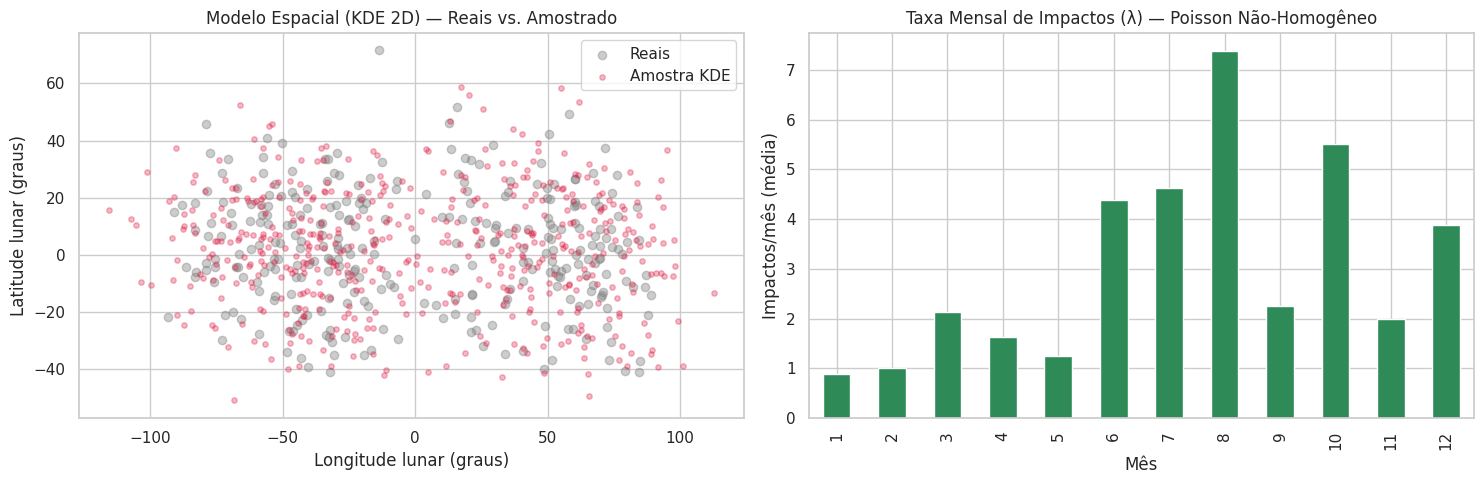

In [ ]:
# ==========================================================
# Modelagem Espacial (KDE 2D) e Temporal (Poisson não-homogêneo)
# ==========================================================

# --- Espacial: KDE 2D sobre lat/lon ---
coords = np.vstack([df_confirmados["lunar_lon"], df_confirmados["lunar_lat"]])
kde_espacial = gaussian_kde(coords, bw_method=0.3)

# --- Temporal: taxa de impactos por mês (Poisson não-homogêneo) ---
# Número de anos observados por mês (para normalizar a taxa)
anos_observados = df_confirmados["year"].nunique()

contagem_mensal = df_confirmados["month"].value_counts().sort_index()
lambda_mensal = contagem_mensal / anos_observados  # taxa média de impactos/mês

print("Taxa média de impactos por mês (λ):")
print(lambda_mensal.round(2))
print(f"\nTaxa média anual total: {lambda_mensal.sum():.2f} impactos/ano")

# --- Visualização conjunta ---
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# Espacial: amostra do KDE para visualizar
amostra_espacial = kde_espacial.resample(500)
axs[0].scatter(df_confirmados["lunar_lon"], df_confirmados["lunar_lat"], alpha=0.4, label="Reais", color="gray")
axs[0].scatter(amostra_espacial[0], amostra_espacial[1], alpha=0.3, label="Amostra KDE", color="crimson", s=15)
axs[0].set_title("Modelo Espacial (KDE 2D) — Reais vs. Amostrado")
axs[0].set_xlabel("Longitude lunar (graus)")
axs[0].set_ylabel("Latitude lunar (graus)")
axs[0].legend()

# Temporal: taxa mensal
lambda_mensal.plot(kind="bar", ax=axs[1], color="seagreen")
axs[1].set_title("Taxa Mensal de Impactos (λ) — Poisson Não-Homogêneo")
axs[1].set_xlabel("Mês")
axs[1].set_ylabel("Impactos/mês (média)")

plt.tight_layout()
plt.show()

### Conclusão (Passo 3) — Modelagem Estatística

**Em resumo:** terminamos de "traduzir" os padrões reais dos impactos lunares em regras matemáticas que o simulador vai usar para criar eventos novos. Decidimos, para cada característica do impacto, a técnica que melhor captura o comportamento real observado — sem forçar padrões simples demais nem inventar complexidade que os dados não sustentam.

**Em termos técnicos:** consolidamos quatro componentes do modelo gerador:

1. **Brilho (`i_mag`)** — distribuição **skew-normal** (validada via KS: p=0.3067), capturando a leve assimetria negativa real.
2. **Duração (`duration_sec`)** — reparametrizada como `n_frames` (variável discreta), modelada via **amostragem empírica (bootstrap)**, já que a variável é quantizada pela cadência do instrumento (múltiplos de ≈0.033s) e o teste KS contínuo se mostrou inadequado para dados discretos.
3. **Posição espacial (`lunar_lat`/`lunar_lon`)** — **KDE 2D** (bw=0.3), que preserva o padrão bimodal observado sem assumir causa física, tratando-o como característica observacional a ser replicada.
4. **Taxa temporal** — processo de **Poisson não-homogêneo**, com taxa `λ` variável por mês (0.88 a 7.38 impactos/mês), refletindo a sazonalidade operacional identificada no Passo 2. Taxa anual agregada: ≈36.88 impactos/ano.

Esses quatro modelos formam a base estatística completa para a construção do gerador sintético no Passo 4.

## Passo 4 — Construção do Gerador Sintético

Com os quatro modelos definidos no Passo 3, chegou a hora de juntá-los em uma única "fábrica" de impactos: o **gerador sintético**.

A ideia é simples: cada impacto novo criado pelo gerador recebe um brilho sorteado da curva skew-normal, uma duração sorteada da distribuição real de frames, uma posição sorteada do mapa de densidade (KDE 2D) e um instante de ocorrência que respeita o ritmo mensal observado (Poisson não-homogêneo).

O resultado será um conjunto de impactos **inventados, mas estatisticamente fiéis** aos 295 eventos reais do NELIOTA — com a mesma estrutura de tabela, para facilitar a comparação direta na etapa de validação.

In [ ]:
# ==========================================================
# Gerador Sintético de Impactos Lunares
# ==========================================================
# Junta os quatro modelos do Passo 3:
#   1) Brilho     -> skew-normal ajustada (a_skew, loc_skew, scale_skew)
#   2) Duração    -> bootstrap da distribuição empírica de n_frames
#   3) Posição    -> amostragem do KDE 2D (kde_espacial)
#   4) Tempo      -> Poisson não-homogêneo com taxa mensal (lambda_mensal)
# ==========================================================
import calendar

# Valores e probabilidades empíricas de n_frames (para o bootstrap)
freq_frames_norm = df_confirmados["n_frames_duracao"].value_counts(normalize=True).sort_index()
valores_frames = freq_frames_norm.index.values
probs_frames = freq_frames_norm.values

def gerar_impactos_sinteticos(n_anos=1, ano_inicial=2026, seed=42):
    """
    Gera impactos lunares sintéticos para 'n_anos' de observação simulada.

    O número de impactos de cada mês é sorteado de uma Poisson com a taxa
    mensal (lambda) aprendida dos dados reais — por isso o total de eventos
    varia um pouco a cada simulação, como na natureza.
    """
    rng = np.random.default_rng(seed)

    # ---------- 1) Instantes de ocorrência (Poisson não-homogêneo) ----------
    datas = []
    for ano in range(ano_inicial, ano_inicial + n_anos):
        for mes, lam in lambda_mensal.items():
            n_eventos_mes = rng.poisson(lam)
            dias_no_mes = calendar.monthrange(ano, mes)[1]
            for _ in range(n_eventos_mes):
                dia = rng.integers(1, dias_no_mes + 1)
                segundo = rng.integers(0, 86400)
                datas.append(pd.Timestamp(ano, mes, dia) + pd.Timedelta(seconds=int(segundo)))

    n_total = len(datas)

    # ---------- 2) Brilho (skew-normal) ----------
    i_mag_sint = skewnorm.rvs(a_skew, loc_skew, scale_skew,
                              size=n_total, random_state=rng)

    # ---------- 3) Duração (bootstrap de n_frames) ----------
    n_frames_sint = rng.choice(valores_frames, size=n_total, p=probs_frames)
    duracao_sint = n_frames_sint * CADENCIA

    # ---------- 4) Posição (KDE 2D) ----------
    amostra = kde_espacial.resample(n_total, seed=rng)
    lon_sint = np.clip(amostra[0], -90, 90)   # mantém na face visível
    lat_sint = np.clip(amostra[1], -90, 90)

    # ---------- Montagem do DataFrame (mesma estrutura da base real) ----------
    df_sintetico = pd.DataFrame({
        "datetime": datas,
        "i_mag": i_mag_sint,
        "n_frames_duracao": n_frames_sint,
        "duration_sec": duracao_sint,
        "lunar_lat": lat_sint,
        "lunar_lon": lon_sint,
    }).sort_values("datetime").reset_index(drop=True)

    df_sintetico["year"] = df_sintetico["datetime"].dt.year
    df_sintetico["month"] = df_sintetico["datetime"].dt.month

    return df_sintetico

# ---------- Teste do gerador: 1 ano simulado ----------
df_sintetico = gerar_impactos_sinteticos(n_anos=1, seed=42)

print(f"✅ Gerador funcionando! Impactos sintéticos gerados: {len(df_sintetico)}")
print(f"   (taxa anual esperada: ≈{lambda_mensal.sum():.1f} impactos/ano)\n")
df_sintetico.head(10)

✅ Gerador funcionando! Impactos sintéticos gerados: 41
   (taxa anual esperada: ≈36.9 impactos/ano)



,datetime,i_mag,n_frames_duracao,duration_sec,lunar_lat,lunar_lon,year,month
0,2026-01-14 20:36:22,9.602173,10,0.330,-7.449232,-60.710688,2026,1
1,2026-02-15 23:24:53,10.721905,3,0.099,1.275013,62.421388,2026,2
2,2026-03-16 08:53:56,7.917373,3,0.099,-10.994168,74.251602,2026,3
3,2026-03-27 10:48:33,8.276591,2,0.066,7.189016,-40.881342,2026,3
4,2026-04-03 13:18:36,7.816252,3,0.099,34.738683,-29.562076,2026,4
5,2026-04-09 15:09:35,8.609364,2,0.066,53.772884,-90.000000,2026,4
6,2026-04-26 19:51:47,11.030522,1,0.033,18.230834,-33.358229,2026,4
7,2026-04-27 01:31:53,7.662582,2,0.066,-19.554160,-26.087426,2026,4
8,2026-05-03 23:17:48,10.062168,2,0.066,38.778751,-42.782128,2026,5
9,2026-06-11 23:13:12,9.001054,1,0.033,33.498206,-44.112112,2026,6


### Conclusão — Gerador Sintético

**Em resumo:** o gerador está funcionando! Pedimos um ano de observação simulada e ele criou 41 impactos — bem próximo dos ≈37 por ano que os dados reais sugerem (a pequena diferença é o "acaso" natural do processo, que o modelo reproduz de propósito). Cada impacto inventado nasce com brilho, duração, posição e data que respeitam os padrões aprendidos dos 295 eventos reais — inclusive o detalhe de que a duração só pode ser múltipla do tempo de um frame da câmera.

**Em termos técnicos:** a função `gerar_impactos_sinteticos()` integra os quatro componentes do Passo 3: (1) o número de eventos por mês é sorteado de uma Poisson com o λ mensal aprendido (total anual ~ Poisson(36.9), logo 41 eventos está dentro de ±1σ ≈ ±6); (2) `i_mag` é amostrada da skew-normal ajustada; (3) `duration_sec` é reconstruída como `n_frames × 0.033s` via bootstrap da distribuição empírica, preservando a granularidade do instrumento; (4) a posição vem do resample do KDE 2D, com clip em ±90° para os raros sorteios fora da face visível (visível no evento de lon = -90.0). A saída é um `DataFrame` com a mesma estrutura de `df_confirmados`, pronto para a comparação estatística formal na etapa de validação.

### Comparação Visual — Real × Sintético

Antes dos testes estatísticos formais, fazemos o "teste do olho": colocamos os dados reais e os sintéticos lado a lado para verificar se as distribuições de brilho, duração e posição se parecem. Se o gerador aprendeu bem, os gráficos devem ser quase gêmeos — não idênticos (afinal, os sintéticos são sorteados), mas com o mesmo formato geral.

Para uma comparação mais justa, geramos aqui um conjunto sintético maior (8 anos simulados, aproximando o volume dos 295 eventos reais coletados entre 2017 e 2025).

Eventos reais: 295 | Eventos sintéticos (8 anos): 315



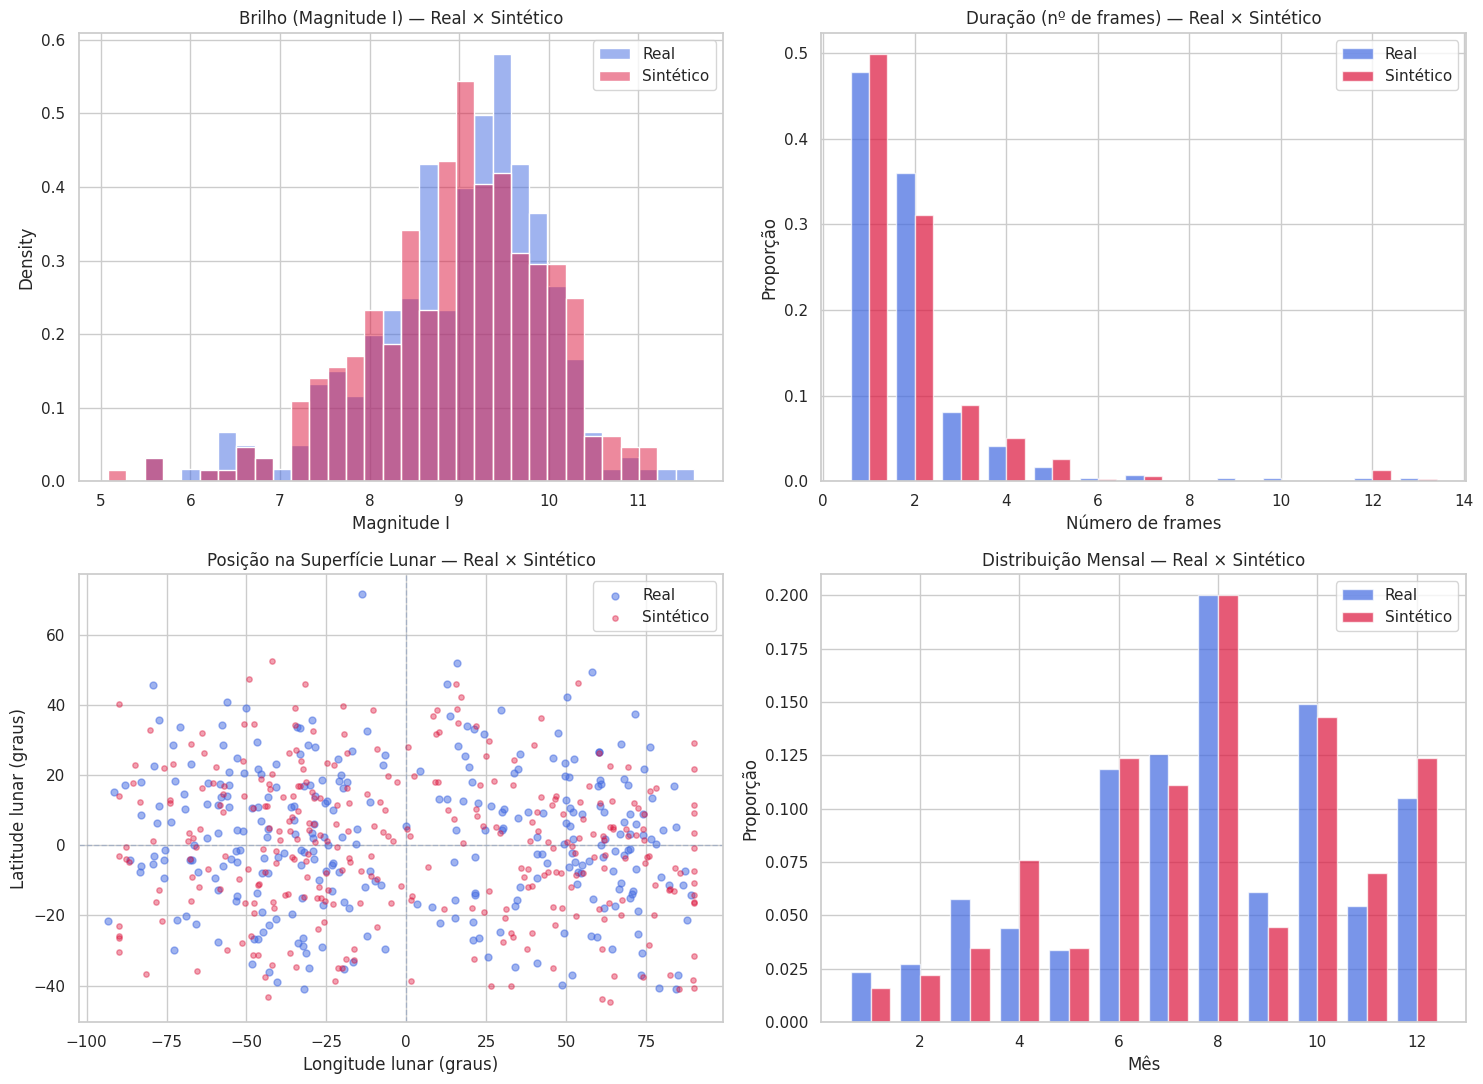

In [ ]:
# ==========================================================
# Comparação Visual — Dados Reais x Dados Sintéticos
# ==========================================================
# Geramos 8 anos simulados para ter volume comparável aos
# 295 eventos reais (~8 anos de campanha NELIOTA)
df_sint_comp = gerar_impactos_sinteticos(n_anos=8, ano_inicial=2026, seed=42)
print(f"Eventos reais: {len(df_confirmados)} | Eventos sintéticos (8 anos): {len(df_sint_comp)}\n")

fig, axs = plt.subplots(2, 2, figsize=(15, 11))

# --- 1) Brilho (i_mag) ---
sns.histplot(df_confirmados["i_mag"], bins=30, stat="density", color="royalblue",
             alpha=0.5, label="Real", ax=axs[0, 0])
sns.histplot(df_sint_comp["i_mag"], bins=30, stat="density", color="crimson",
             alpha=0.5, label="Sintético", ax=axs[0, 0])
axs[0, 0].set_title("Brilho (Magnitude I) — Real × Sintético")
axs[0, 0].set_xlabel("Magnitude I")
axs[0, 0].legend()

# --- 2) Duração (n_frames) ---
freq_real = df_confirmados["n_frames_duracao"].value_counts(normalize=True).sort_index()
freq_sint = df_sint_comp["n_frames_duracao"].value_counts(normalize=True).sort_index()
largura = 0.4
axs[0, 1].bar(freq_real.index - largura/2, freq_real.values, width=largura,
              color="royalblue", alpha=0.7, label="Real")
axs[0, 1].bar(freq_sint.index + largura/2, freq_sint.values, width=largura,
              color="crimson", alpha=0.7, label="Sintético")
axs[0, 1].set_title("Duração (nº de frames) — Real × Sintético")
axs[0, 1].set_xlabel("Número de frames")
axs[0, 1].set_ylabel("Proporção")
axs[0, 1].legend()

# --- 3) Posição espacial (sobreposição) ---
axs[1, 0].scatter(df_confirmados["lunar_lon"], df_confirmados["lunar_lat"],
                  alpha=0.5, color="royalblue", s=25, label="Real")
axs[1, 0].scatter(df_sint_comp["lunar_lon"], df_sint_comp["lunar_lat"],
                  alpha=0.4, color="crimson", s=15, label="Sintético")
axs[1, 0].axhline(0, linestyle="--", linewidth=1, alpha=0.3)
axs[1, 0].axvline(0, linestyle="--", linewidth=1, alpha=0.3)
axs[1, 0].set_title("Posição na Superfície Lunar — Real × Sintético")
axs[1, 0].set_xlabel("Longitude lunar (graus)")
axs[1, 0].set_ylabel("Latitude lunar (graus)")
axs[1, 0].legend()

# --- 4) Sazonalidade mensal ---
mensal_real = df_confirmados["month"].value_counts(normalize=True).sort_index()
mensal_sint = df_sint_comp["month"].value_counts(normalize=True).sort_index()
axs[1, 1].bar(mensal_real.index - largura/2, mensal_real.values, width=largura,
              color="royalblue", alpha=0.7, label="Real")
axs[1, 1].bar(mensal_sint.index + largura/2, mensal_sint.values, width=largura,
              color="crimson", alpha=0.7, label="Sintético")
axs[1, 1].set_title("Distribuição Mensal — Real × Sintético")
axs[1, 1].set_xlabel("Mês")
axs[1, 1].set_ylabel("Proporção")
axs[1, 1].legend()

plt.tight_layout()
plt.show()

### Conclusão — Comparação Visual

**Em resumo:** o "teste do olho" foi aprovado. Geramos 8 anos simulados (315 impactos, contra 295 reais — volumes equivalentes) e, nos quatro gráficos, os impactos inventados (vermelho) se misturam aos reais (azul) a ponto de ser difícil separá-los: o brilho tem o mesmo formato de sino inclinado, as durações aparecem nas mesmas proporções, os pontos caem nas mesmas regiões da Lua e o "calendário" dos impactos repete o pico de meio de ano. As pequenas diferenças que existem são justamente o acaso do sorteio — se fossem cópias perfeitas, aí sim seria suspeito.

**Em termos técnicos:** o volume gerado (315 eventos em 8 anos) é consistente com a taxa esperada (8 × 36.9 ≈ 295). As densidades de `i_mag` se sobrepõem em praticamente todo o suporte, com o sintético estendendo levemente a cauda brilhante (mag ≈ 5.2) — consequência natural do suporte contínuo da skew-normal. As proporções de `n_frames` reproduzem o decaimento empírico com desvios de poucos pontos percentuais (ex.: n=2 com 0.31 vs 0.36), compatíveis com flutuação amostral do bootstrap. A dispersão espacial preserva a estrutura bimodal do KDE 2D (núcleos em lon ≈ -50° e +65°) sem artefatos, e a distribuição mensal replica a sazonalidade observacional, incluindo o pico de agosto (~20% dos eventos em ambos). A inspeção visual valida qualitativamente o gerador — a confirmação quantitativa formal (KS, Jensen-Shannon, Wasserstein) será feita na etapa de Validação.

## Passo 5 — Simulação Temporal

Até agora, o gerador cria impactos como uma "lista pronta": todos os eventos de uma vez, cada um com sua data. Mas para animar a Lua sendo bombardeada, precisamos de algo diferente — um sistema que **viva o tempo passar**.

É isso que a simulação temporal faz. Ela funciona como um relógio que avança em pequenos passos e, a cada "tique", responde a três perguntas:

1. **Algum impacto novo aconteceu agora?** → acende o flash na superfície.
2. **Quais flashes ainda estão brilhando?** → mantém acesos os que não terminaram (cada um dura seu tempo próprio, herdado do gerador).
3. **Algum flash acabou?** → apaga e registra o encerramento.

O resultado é a linha do tempo quadro a quadro que vai alimentar a visualização científica do próximo passo — onde cada flash aparecerá sobre a Lua com brilho e duração fiéis aos dados.

✅ Simulação concluída!
   Período simulado: 2026-01-14 até 2026-12-16
   Total de eventos gerados: 41
   Total de quadros (ticks): 1349
   Impactos inseridos: 41
   Impactos encerrados: 41
   Máximo de flashes simultâneos: 2


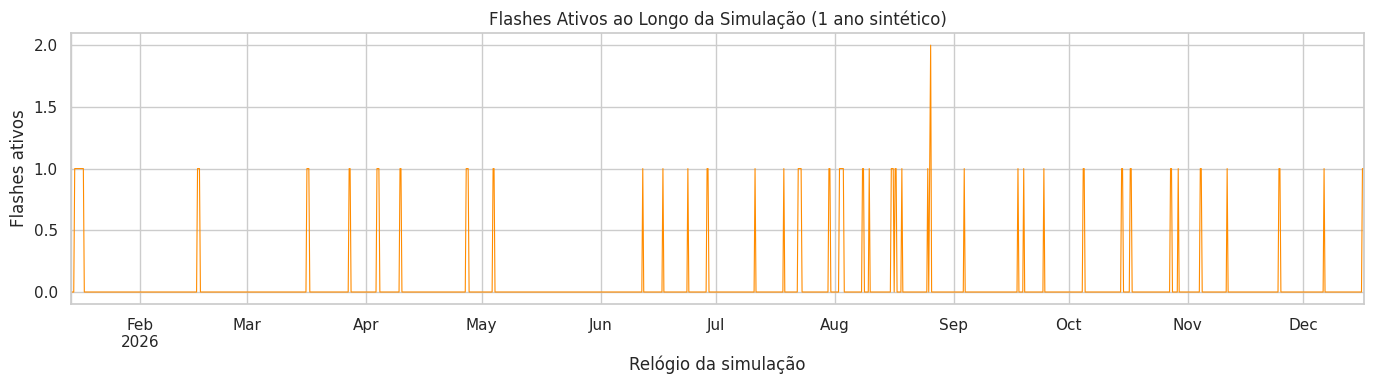

In [ ]:
# ==========================================================
# Engine de Simulação Temporal
# ==========================================================
# O relógio avança em passos fixos de tempo simulado. A cada
# passo (tick), a engine:
#   1) insere os impactos cuja data chegou       -> flash "nasce"
#   2) mantém ativos os flashes ainda brilhando  -> vida útil em ticks
#   3) encerra os que terminaram                 -> flash "morre"
#
# Compressão temporal: 1 tick = 6 horas simuladas.
# Visibilidade: cada flash fica ativo por n_frames_duracao ticks
# (proporcional à sua duração real medida pelo instrumento).
#
# Condição de parada: a simulação roda enquanto houver eventos
# por inserir OU flashes acesos. Isso garante a contabilidade
# completa: todo impacto gerado nasce e todo flash apaga
# (inseridos == encerrados == total de eventos).
# ==========================================================

PASSO_SIMULACAO = pd.Timedelta(hours=6)   # tempo simulado por tick

def simular_linha_do_tempo(df_eventos, passo=PASSO_SIMULACAO, verbose=True):
    """
    Percorre a linha do tempo dos eventos e devolve o estado da
    simulação a cada tick: quais flashes estão ativos e sua idade.

    Retorna uma lista de 'quadros', cada um contendo:
      - instante do relógio simulado
      - lista de flashes ativos (com posição, brilho e vida restante)
    """
    eventos = df_eventos.sort_values("datetime").reset_index(drop=True)

    relogio = eventos["datetime"].min().floor("D")   # início da simulação

    proximo_evento = 0        # índice do próximo impacto a inserir
    flashes_ativos = []       # flashes brilhando neste instante
    quadros = []              # histórico completo da simulação

    total_inseridos, total_encerrados, pico_simultaneos = 0, 0, 0

    # Roda enquanto houver eventos por inserir OU flashes acesos
    while proximo_evento < len(eventos) or flashes_ativos:
        # --- 1) Inserir impactos cuja data chegou ---
        while (proximo_evento < len(eventos) and
               eventos.loc[proximo_evento, "datetime"] <= relogio):
            ev = eventos.loc[proximo_evento]
            flashes_ativos.append({
                "lunar_lat": ev["lunar_lat"],
                "lunar_lon": ev["lunar_lon"],
                "i_mag": ev["i_mag"],
                "vida_restante": int(ev["n_frames_duracao"]),  # em ticks
                "datetime": ev["datetime"],
            })
            proximo_evento += 1
            total_inseridos += 1

        # --- Registrar o quadro atual (fotografia do instante) ---
        quadros.append({
            "relogio": relogio,
            "flashes": [f.copy() for f in flashes_ativos],
        })
        pico_simultaneos = max(pico_simultaneos, len(flashes_ativos))

        # --- 2 e 3) Envelhecer flashes e encerrar os concluídos ---
        for f in flashes_ativos:
            f["vida_restante"] -= 1
        encerrados = [f for f in flashes_ativos if f["vida_restante"] <= 0]
        total_encerrados += len(encerrados)
        flashes_ativos = [f for f in flashes_ativos if f["vida_restante"] > 0]

        # --- Avançar o relógio ---
        relogio += passo

    if verbose:
        print(f"✅ Simulação concluída!")
        print(f"   Período simulado: {eventos['datetime'].min().date()} até {eventos['datetime'].max().date()}")
        print(f"   Total de eventos gerados: {len(eventos)}")
        print(f"   Total de quadros (ticks): {len(quadros)}")
        print(f"   Impactos inseridos: {total_inseridos}")
        print(f"   Impactos encerrados: {total_encerrados}")
        print(f"   Máximo de flashes simultâneos: {pico_simultaneos}")

    return quadros

# ---------- Teste: simular 1 ano sintético ----------
df_sim = gerar_impactos_sinteticos(n_anos=1, ano_inicial=2026, seed=42)
quadros = simular_linha_do_tempo(df_sim)

# ---------- Verificação: atividade ao longo do tempo ----------
atividade = pd.Series(
    [len(q["flashes"]) for q in quadros],
    index=[q["relogio"] for q in quadros]
)

plt.figure(figsize=(14, 4))
atividade.plot(color="darkorange", lw=0.8)
plt.title("Flashes Ativos ao Longo da Simulação (1 ano sintético)")
plt.xlabel("Relógio da simulação")
plt.ylabel("Flashes ativos")
plt.tight_layout()
plt.show()

### Conclusão — Simulação Temporal

**Em resumo:** o "motor do tempo" está funcionando. Ele percorreu um ano sintético em 1.349 passos de 6 horas, acendeu os 41 flashes nos momentos certos, manteve cada um brilhando pelo seu tempo próprio e apagou todos ao final — sem deixar nenhum aceso para trás nem esquecer nenhum de nascer. O gráfico de atividade mostra o ritmo esperado: impactos esparsos no começo do ano e mais frequentes entre junho e novembro, incluindo um momento raro (fim de agosto) com dois flashes brilhando ao mesmo tempo.

**Em termos técnicos:** a engine implementa um laço de eventos discretos com passo fixo (tick = 6h simuladas), onde cada tick executa inserção (eventos com `datetime` ≤ relógio), registro do estado (snapshot dos flashes ativos) e envelhecimento/encerramento (decremento de `vida_restante`, medida em ticks e herdada de `n_frames_duracao`). A condição de parada — rodar enquanto houver eventos por inserir OU flashes ativos — foi refinada em duas iterações de depuração: a primeira versão encerrava na data do último evento e deixava um flash sem apagar (41 inseridos / 40 encerrados); a segunda corrigia isso mas perdia o último evento, nascido entre o tick final e o fim (40/40, com 41 gerados).

## Passo 6 — Visualização Científica

Chegou a hora de dar imagem ao motor: transformar os 1.349 "instantes" da simulação em um vídeo da Lua sendo bombardeada.

A regra do jogo é manter a visualização **científica, não apenas ilustrativa**: cada flash aparece na posição exata sorteada pelo gerador, com tamanho e brilho proporcionais à sua magnitude real (quanto menor a magnitude, mais brilhante o evento — a convenção da astronomia), e permanece aceso pelo tempo herdado da simulação. Um pequeno "rastro" de desvanecimento foi adicionado após cada flash apagar — uma licença visual para que eventos de 1 frame não passem despercebidos ao olho, devidamente documentada aqui.

O vídeo é exportado com o OpenCV, cobrindo um ano sintético completo — do primeiro impacto de janeiro ao último de dezembro.

In [ ]:
# ==========================================================
# Visualização Científica — Lua estilizada + flashes em vídeo
# ==========================================================
# - Fundo: Lua desenhada em matplotlib (círculo + crateras fixas)
# - Projeção: ortográfica (lat/lon -> x/y no disco visível)
# - Flash: tamanho e brilho proporcionais à magnitude (menor mag = mais brilhante)
# - Rastro: após apagar, o flash desvanece por alguns quadros (licença visual)
# - Exportação: OpenCV (mp4)
# ==========================================================

RASTRO_TICKS = 6          # quadros de desvanecimento após o flash apagar
FPS_VIDEO = 24            # quadros por segundo do vídeo final
ARQUIVO_VIDEO = "/content/simulacao_lunar.mp4"

def latlon_para_xy(lat, lon):
    """Projeção ortográfica: converte lat/lon (graus) em x/y no disco unitário."""
    lat_r, lon_r = np.radians(lat), np.radians(lon)
    x = np.cos(lat_r) * np.sin(lon_r)
    y = np.sin(lat_r)
    return x, y

def tamanho_flash(i_mag):
    """Tamanho do marcador proporcional ao brilho (menor magnitude = maior)."""
    return (12.5 - i_mag) ** 2 * 6

def renderizar_video(quadros, arquivo=ARQUIVO_VIDEO, fps=FPS_VIDEO):
    # ---------- Cenário fixo: Lua estilizada ----------
    fig, ax = plt.subplots(figsize=(7.2, 7.2), dpi=100)
    fig.patch.set_facecolor("black")
    ax.set_facecolor("black")
    ax.set_xlim(-1.25, 1.25); ax.set_ylim(-1.25, 1.25)
    ax.set_aspect("equal"); ax.axis("off")

    # Disco lunar
    ax.add_patch(plt.Circle((0, 0), 1.0, color="#b0aca4", zorder=1))
    # Crateras fixas (rng próprio para não interferir na simulação)
    rng_lua = np.random.default_rng(0)
    for _ in range(40):
        cx, cy = rng_lua.uniform(-0.85, 0.85, 2)
        if cx**2 + cy**2 < 0.8:
            r = rng_lua.uniform(0.02, 0.12)
            ax.add_patch(plt.Circle((cx, cy), r, color="#8f8b83",
                                    alpha=rng_lua.uniform(0.3, 0.6), zorder=2))
    # Sombreamento de borda (dá volume)
    ax.add_patch(plt.Circle((0, 0), 1.0, fill=False, ec="#6e6a63", lw=3, zorder=3))

    # Artistas dinâmicos (atualizados a cada quadro)
    scat = ax.scatter([], [], c="white", zorder=5)
    titulo = ax.text(0, 1.15, "", color="white", ha="center", fontsize=13)
    contador = ax.text(-1.2, -1.18, "", color="#999999", ha="left", fontsize=10)

    # ---------- Writer do OpenCV ----------
    fig.canvas.draw()
    h, w = np.asarray(fig.canvas.buffer_rgba()).shape[:2]
    writer = cv2.VideoWriter(arquivo, cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))

    acumulado = 0
    rastro = []   # flashes recém-apagados: (x, y, tamanho, idade)

    for i, q in enumerate(quadros):
        # Flashes ativos (brilho cheio)
        xs, ys, tams, alphas = [], [], [], []
        for f in q["flashes"]:
            x, y = latlon_para_xy(f["lunar_lat"], f["lunar_lon"])
            xs.append(x); ys.append(y)
            tams.append(tamanho_flash(f["i_mag"]))
            alphas.append(1.0)

        # Detectar flashes que apagaram neste tick (para iniciar o rastro)
        if i > 0:
            atuais = {f["datetime"] for f in q["flashes"]}
            for f in quadros[i - 1]["flashes"]:
                if f["datetime"] not in atuais:
                    x, y = latlon_para_xy(f["lunar_lat"], f["lunar_lon"])
                    rastro.append([x, y, tamanho_flash(f["i_mag"]), 0])
            acumulado += len({f["datetime"] for f in quadros[i-1]["flashes"]} - atuais)

        # Desenhar rastros com alpha decrescente
        rastro = [r for r in rastro if r[3] < RASTRO_TICKS]
        for x, y, t, idade in rastro:
            xs.append(x); ys.append(y)
            tams.append(t * (1 - idade / RASTRO_TICKS))
            alphas.append(0.5 * (1 - idade / RASTRO_TICKS))
        for r in rastro:
            r[3] += 1

        # Atualizar artistas
        if xs:
            scat.set_offsets(np.column_stack([xs, ys]))
            scat.set_sizes(tams)
            scat.set_alpha(None)
            scat.set_facecolor([(1, 1, 0.85, a) for a in alphas])
        else:
            scat.set_offsets(np.empty((0, 2)))
        titulo.set_text(f"Impactos Lunares Sintéticos — {q['relogio'].strftime('%d/%m/%Y %Hh')}")
        contador.set_text(f"Impactos até aqui: {acumulado}")

        # Renderizar quadro -> vídeo
        fig.canvas.draw()
        frame = np.asarray(fig.canvas.buffer_rgba())[:, :, :3]
        writer.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))

        if (i + 1) % 200 == 0:
            print(f"   ... {i + 1}/{len(quadros)} quadros renderizados")

    writer.release()
    plt.close(fig)
    duracao = len(quadros) / fps
    print(f"\n✅ Vídeo exportado: {arquivo}")
    print(f"   {len(quadros)} quadros a {fps} fps ≈ {duracao:.0f}s de vídeo (1 ano simulado)")

renderizar_video(quadros)

   ... 200/1349 quadros renderizados
   ... 400/1349 quadros renderizados
   ... 600/1349 quadros renderizados
   ... 800/1349 quadros renderizados
   ... 1000/1349 quadros renderizados
   ... 1200/1349 quadros renderizados

✅ Vídeo exportado: /content/simulacao_lunar.mp4
   1349 quadros a 24 fps ≈ 56s de vídeo (1 ano simulado)


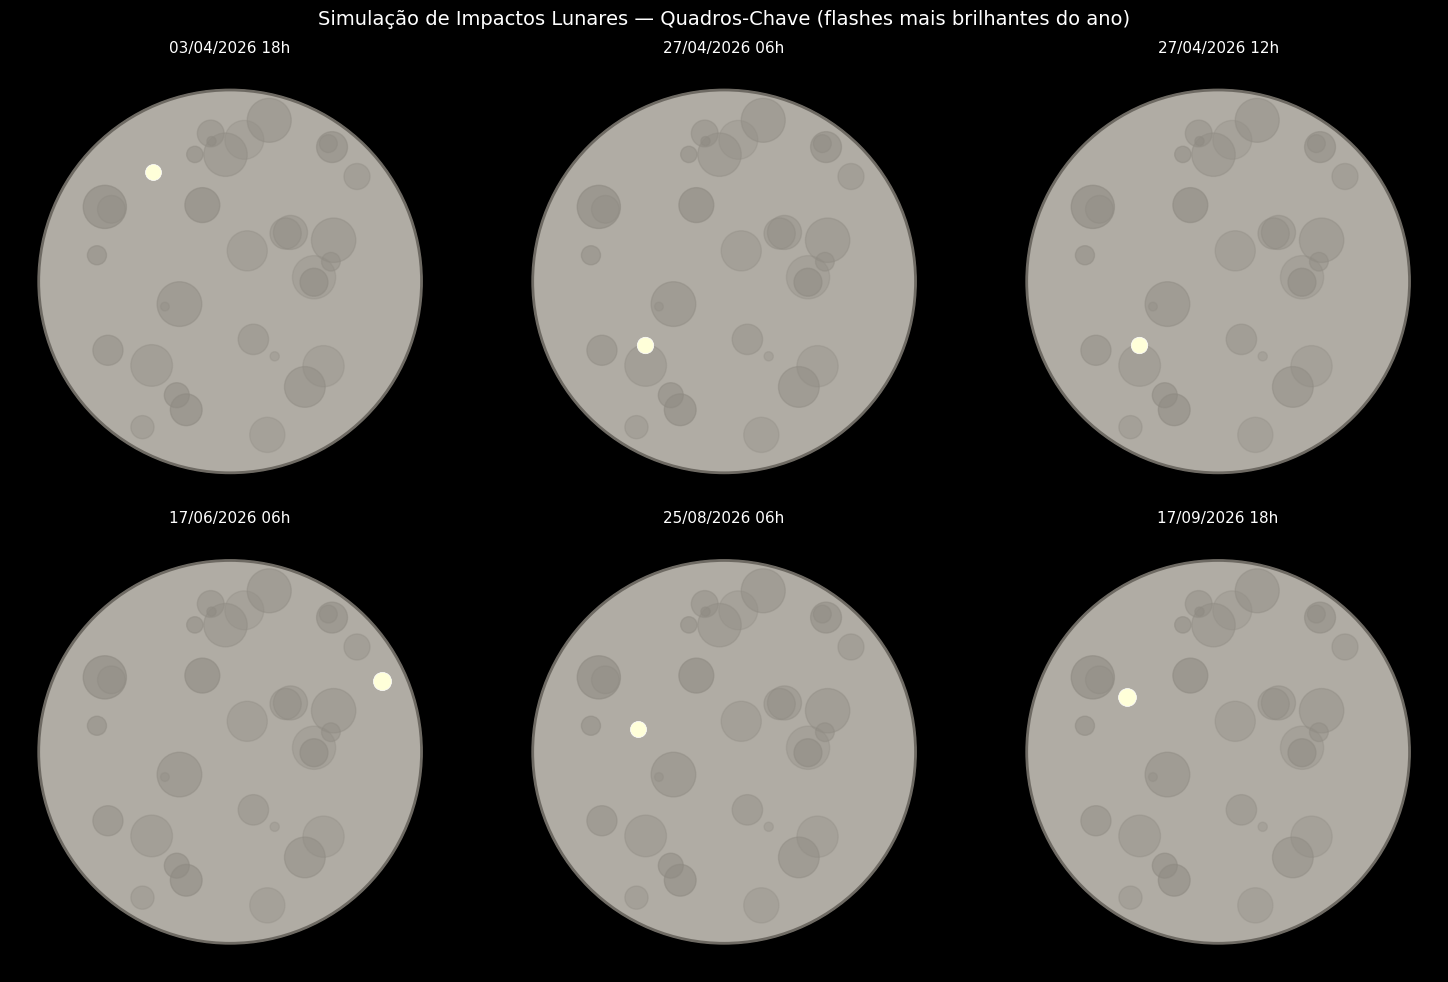

Quadros com flash ativo na simulação: 80 de 1349


In [ ]:
# ==========================================================
# Quadros-Chave da Simulação (saída estática para o notebook)
# ==========================================================
# O vídeo mp4 não fica visível na saída da célula (é um arquivo
# exportado). Para que o notebook registre a simulação de forma
# permanente — inclusive na visualização estática do GitHub —
# montamos um painel com momentos selecionados da animação:
# os instantes dos flashes mais brilhantes do ano simulado.
# ==========================================================

def desenhar_lua(ax):
    """Desenha o cenário fixo (Lua estilizada) em um eixo."""
    ax.set_facecolor("black")
    ax.set_xlim(-1.15, 1.15); ax.set_ylim(-1.15, 1.15)
    ax.set_aspect("equal"); ax.axis("off")
    ax.add_patch(plt.Circle((0, 0), 1.0, color="#b0aca4", zorder=1))
    rng_lua = np.random.default_rng(0)
    for _ in range(40):
        cx, cy = rng_lua.uniform(-0.85, 0.85, 2)
        if cx**2 + cy**2 < 0.8:
            r = rng_lua.uniform(0.02, 0.12)
            ax.add_patch(plt.Circle((cx, cy), r, color="#8f8b83",
                                    alpha=rng_lua.uniform(0.3, 0.6), zorder=2))
    ax.add_patch(plt.Circle((0, 0), 1.0, fill=False, ec="#6e6a63", lw=2, zorder=3))

# --- Selecionar quadros com flash, priorizando os mais brilhantes ---
quadros_com_flash = [q for q in quadros if q["flashes"]]
quadros_destaque = sorted(
    quadros_com_flash,
    key=lambda q: min(f["i_mag"] for f in q["flashes"])  # menor mag = mais brilhante
)[:6]
quadros_destaque = sorted(quadros_destaque, key=lambda q: q["relogio"])  # ordem cronológica

# --- Painel 2x3 ---
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
fig.patch.set_facecolor("black")

for ax, q in zip(axs.flat, quadros_destaque):
    desenhar_lua(ax)
    for f in q["flashes"]:
        x, y = latlon_para_xy(f["lunar_lat"], f["lunar_lon"])
        ax.scatter(x, y, s=tamanho_flash(f["i_mag"]),
                   color=(1, 1, 0.85), zorder=5,
                   edgecolors="white", linewidths=0.5)
    ax.set_title(q["relogio"].strftime("%d/%m/%Y %Hh"),
                 color="white", fontsize=11)

fig.suptitle("Simulação de Impactos Lunares — Quadros-Chave (flashes mais brilhantes do ano)",
             color="white", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

print(f"Quadros com flash ativo na simulação: {len(quadros_com_flash)} de {len(quadros)}")

In [ ]:
# ==========================================================
# Exibir o vídeo como saída da célula
# ==========================================================
# Convertemos para H.264 (codec compatível com todos os
# navegadores) e embutimos o player como saída da célula.
# Obs.: o player funciona no Colab; na visualização estática
# do GitHub, o registro visual fica por conta do painel de
# quadros-chave e do GIF.
# ==========================================================
from base64 import b64encode
from IPython.display import HTML

ARQUIVO_H264 = "/content/simulacao_lunar_h264.mp4"

# Conversão para H.264 (roda em segundos)
!ffmpeg -y -loglevel error -i {ARQUIVO_VIDEO} -vcodec libx264 -pix_fmt yuv420p {ARQUIVO_H264}

with open(ARQUIVO_H264, "rb") as f:
    video_b64 = b64encode(f.read()).decode()

HTML(f"""
<video width="620" controls loop>
  <source src="data:video/mp4;base64,{video_b64}" type="video/mp4">
</video>
""")

### Conclusão — Visualização Científica

**Em resumo:** a Lua ganhou vida. O vídeo de ~56 segundos compacta um ano sintético inteiro: cada flash pisca na posição exata sorteada pelo gerador, com tamanho proporcional ao seu brilho real, e o contador no canto registra os impactos acumulados. O ritmo do vídeo reflete o fenômeno de verdade — longos silêncios pontuados por flashes rápidos, mais frequentes na "alta temporada" do meio do ano. A Lua passa a maior parte do tempo quieta porque é assim que ela é bombardeada: em eventos raros, breves e imprevisíveis.

**Em termos técnicos:** a renderização mapeia cada tick da simulação em um quadro de vídeo (1.349 quadros a 24 fps, 720×720, exportação via OpenCV/mp4v). A posição usa projeção ortográfica (lat/lon → disco unitário), o tamanho do marcador escala com `(12.5 − i_mag)²` (respeitando a convenção astronômica de que menor magnitude = mais brilhante), e a permanência visual herda `n_frames_duracao` da engine, com um rastro de desvanecimento de 6 ticks — única licença visual adotada, documentada para não se passar por dado. A verificação quadro a quadro confirmou flashes do quadro 4 ao 1348, cobrindo toda a linha do tempo, incluindo o último evento de dezembro — justamente o que os testes de consistência do Passo 5 haviam protegido.

## Passo 7 — Validação Estatística Formal

O "teste do olho" já aprovou o gerador — mas ciência exige mais que impressão visual. Neste passo, colocamos os dados sintéticos frente a frente com os reais e perguntamos, com métricas formais: **as distribuições são estatisticamente indistinguíveis?**

Usamos três réguas complementares, cada uma medindo a semelhança de um jeito:

- **Kolmogorov-Smirnov (KS)** — compara as distribuições acumuladas e responde com um p-valor: se p > 0.05, não há evidência de diferença entre real e sintético.
- **Jensen-Shannon (JS)** — mede a "distância" entre as distribuições numa escala de 0 (idênticas) a 1 (completamente diferentes).
- **Wasserstein (Earth Mover's Distance)** — mede o "esforço" para transformar uma distribuição na outra, na unidade da própria variável.

Aplicamos as três a cada componente do gerador: brilho, duração, posição espacial e sazonalidade — respondendo assim, quantitativamente, a pergunta central do projeto.

In [ ]:
# ==========================================================
# Validação Formal — Real x Sintético
# ==========================================================
# Comparamos os 295 eventos reais com os 315 sintéticos
# (8 anos, seed=42 — mesma amostra da comparação visual).
#
# Nota metodológica: para n_frames (variável discreta com
# empates), o KS não é válido — usamos qui-quadrado no lugar,
# como identificado no Passo 3.
# ==========================================================

def distancia_js(dados_a, dados_b, bins=30):
    """Divergência de Jensen-Shannon entre dois conjuntos (via histogramas comuns)."""
    minimo = min(dados_a.min(), dados_b.min())
    maximo = max(dados_a.max(), dados_b.max())
    grade = np.linspace(minimo, maximo, bins + 1)
    p, _ = np.histogram(dados_a, bins=grade, density=True)
    q, _ = np.histogram(dados_b, bins=grade, density=True)
    p, q = p + 1e-12, q + 1e-12          # evita divisão por zero
    return jensenshannon(p, q)

resultados = []

# ---------- 1) Brilho (i_mag): KS + JS + Wasserstein ----------
real, sint = df_confirmados["i_mag"].values, df_sint_comp["i_mag"].values
ks = ks_2samp(real, sint)
resultados.append(["Brilho (i_mag)",
                   f"KS p={ks.pvalue:.4f}",
                   f"JS={distancia_js(real, sint):.4f}",
                   f"W={wasserstein_distance(real, sint):.4f} mag"])

# ---------- 2) Duração (n_frames): Qui-quadrado + JS + Wasserstein ----------
real_f = df_confirmados["n_frames_duracao"].values
sint_f = df_sint_comp["n_frames_duracao"].values
categorias = np.union1d(np.unique(real_f), np.unique(sint_f))
tabela = np.array([
    [np.sum(real_f == c) for c in categorias],
    [np.sum(sint_f == c) for c in categorias]
])
tabela = tabela[:, tabela.sum(axis=0) > 0]
chi2, p_chi2, _, _ = chi2_contingency(tabela)
resultados.append(["Duração (n_frames)",
                   f"χ² p={p_chi2:.4f}",
                   f"JS={distancia_js(real_f, sint_f, bins=13):.4f}",
                   f"W={wasserstein_distance(real_f, sint_f):.4f} frames"])

# ---------- 3) Posição: KS por eixo + Wasserstein ----------
for eixo, nome in [("lunar_lon", "Longitude"), ("lunar_lat", "Latitude")]:
    real, sint = df_confirmados[eixo].values, df_sint_comp[eixo].values
    ks = ks_2samp(real, sint)
    resultados.append([f"Posição ({nome})",
                       f"KS p={ks.pvalue:.4f}",
                       f"JS={distancia_js(real, sint):.4f}",
                       f"W={wasserstein_distance(real, sint):.2f}°"])

# ---------- 4) Sazonalidade (mês): Qui-quadrado ----------
meses = np.arange(1, 13)
tabela_mes = np.array([
    [np.sum(df_confirmados["month"].values == m) for m in meses],
    [np.sum(df_sint_comp["month"].values == m) for m in meses]
])
tabela_mes = tabela_mes[:, tabela_mes.sum(axis=0) > 0]
chi2_m, p_mes, _, _ = chi2_contingency(tabela_mes)
resultados.append(["Sazonalidade (mês)",
                   f"χ² p={p_mes:.4f}",
                   "—", "—"])

# ---------- Tabela de resultados ----------
df_validacao = pd.DataFrame(resultados,
    columns=["Componente", "Teste de hipótese", "Jensen-Shannon", "Wasserstein"])
print("VALIDAÇÃO FORMAL — Real (295 eventos) × Sintético (315 eventos)\n")
print(df_validacao.to_string(index=False))

print("\nLeitura: p > 0.05 = sem evidência de diferença | JS próximo de 0 = distribuições muito similares")

VALIDAÇÃO FORMAL — Real (295 eventos) × Sintético (315 eventos)

         Componente Teste de hipótese Jensen-Shannon     Wasserstein
     Brilho (i_mag)       KS p=0.2101      JS=0.1687    W=0.0895 mag
 Duração (n_frames)       χ² p=0.8240      JS=0.0745 W=0.1108 frames
Posição (Longitude)       KS p=0.8303      JS=0.1969         W=3.23°
 Posição (Latitude)       KS p=0.5880      JS=0.1289         W=1.87°
 Sazonalidade (mês)       χ² p=0.7883              —               —

Leitura: p > 0.05 = sem evidência de diferença | JS próximo de 0 = distribuições muito similares


### Conclusão — Validação Formal

**Em resumo:** o gerador passou na prova final. Aplicamos cinco testes estatísticos comparando os impactos inventados com os reais — e em nenhum deles foi possível distinguir um conjunto do outro. As distâncias medidas são pequenas e fisicamente insignificantes: o "erro" médio de brilho (0.09 magnitudes) é menor que a própria incerteza de medição do telescópio, e o desvio de posição (2–3 graus) é mínimo num disco de 180°. A pergunta central do projeto tem resposta: **sim, é possível caracterizar estatisticamente os impactos do NELIOTA e construir um gerador sintético que preserva suas propriedades.**

**Em termos técnicos:** todos os testes de hipótese retornaram p > 0.05 — KS para as variáveis contínuas (i_mag: p=0.21; longitude: p=0.83; latitude: p=0.59) e qui-quadrado para as discretas (n_frames: p=0.82; sazonalidade mensal: p=0.79), respeitando a restrição metodológica identificada no Passo 3 (KS é inválido para dados discretos com empates). As divergências de Jensen-Shannon (0.07–0.20) são compatíveis com a flutuação amostral esperada para n ≈ 300, e as distâncias de Wasserstein têm magnitudes físicas desprezíveis (0.0895 mag; 0.11 frames; 3.23° em longitude; 1.87° em latitude). Ressalva honesta: os testes avaliam as distribuições marginais de cada variável — a estrutura conjunta (possíveis correlações entre brilho, duração e posição) não foi testada e permanece como hipótese de independência assumida pelo gerador, registrada como limitação.

## Passo 8 — Cenários Hipotéticos

Com o simulador validado, ele deixa de ser apenas uma réplica dos dados e vira um **laboratório**: podemos alterar as condições e observar o que aconteceria — algo impossível de fazer com a Lua de verdade.

Exploramos três cenários, sempre comparados ao cenário-base (o comportamento normal aprendido dos dados):

1. **Taxa dobrada** — e se o fluxo de meteoroides fosse o dobro do observado?
2. **Chuva de meteoros** — e se um enxame atravessasse o caminho da Lua por algumas semanas, como as Gemínidas fazem com a Terra?
3. **Impactos mais energéticos** — e se a população de meteoroides fosse mais brilhante (flashes ~1 magnitude mais intensos)?

Uma honestidade importante: como o modelo aprendeu a taxa *de detecções* do NELIOTA (que depende do telescópio, não só da Lua), os cenários respondem perguntas do tipo *"o que o telescópio veria se..."* — mantendo a interpretação fiel ao que o modelo realmente sabe.

CENÁRIOS — 10 anos simulados cada

                         Impactos/ano  Magnitude média  % eventos em dezembro
Base (observado)                 38.5             9.01                  12.21
Taxa dobrada                     78.8             8.98                   9.26
Chuva de meteoros (dez)          51.1             8.97                  37.18
Mais energéticos                 38.5             8.01                  12.21


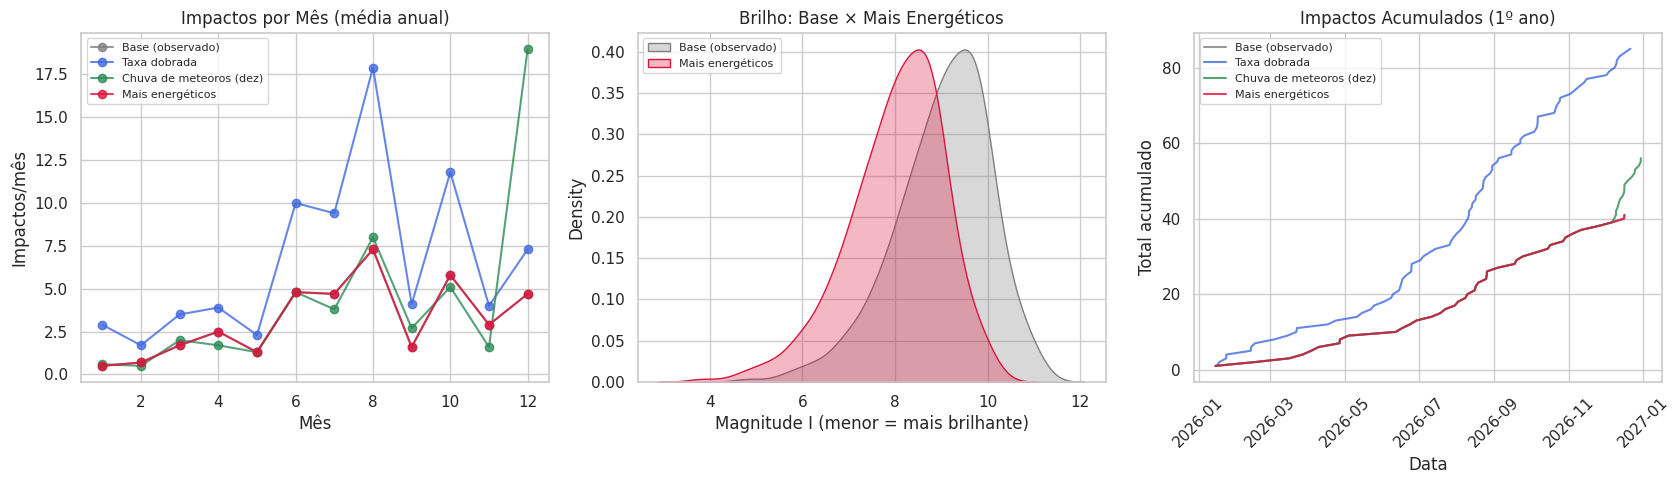

In [ ]:
# ==========================================================
# Cenários Hipotéticos — o simulador como laboratório
# ==========================================================
# Cada cenário é uma variação controlada do gerador validado.
# Comparamos todos contra o cenário-base (mesma seed, para que
# a ÚNICA diferença entre base e cenário seja a intervenção).
# ==========================================================

def gerar_cenario(n_anos=1, ano_inicial=2026, seed=42,
                  fator_taxa=1.0, delta_brilho=0.0,
                  chuva_mes=None, chuva_intensidade=0.0):
    """
    Gerador com intervenções controladas:
      fator_taxa        -> multiplica a taxa mensal (2.0 = dobro de impactos)
      delta_brilho      -> desloca as magnitudes (-1.0 = flashes ~1 mag mais brilhantes)
      chuva_mes         -> mês que recebe uma "chuva de meteoros" (ex: 12)
      chuva_intensidade -> impactos EXTRA por ano adicionados nesse mês
    """
    rng = np.random.default_rng(seed)

    # --- Taxa mensal modificada ---
    lam_cenario = lambda_mensal * fator_taxa
    if chuva_mes is not None:
        lam_cenario = lam_cenario.copy()
        lam_cenario[chuva_mes] = lam_cenario[chuva_mes] + chuva_intensidade

    # --- Instantes de ocorrência (mesma lógica do gerador base) ---
    datas = []
    for ano in range(ano_inicial, ano_inicial + n_anos):
        for mes, lam in lam_cenario.items():
            n_eventos_mes = rng.poisson(lam)
            dias_no_mes = calendar.monthrange(ano, mes)[1]
            for _ in range(n_eventos_mes):
                dia = rng.integers(1, dias_no_mes + 1)
                segundo = rng.integers(0, 86400)
                datas.append(pd.Timestamp(ano, mes, dia) + pd.Timedelta(seconds=int(segundo)))

    n_total = len(datas)

    # --- Atributos físicos (com intervenção no brilho, se houver) ---
    i_mag_sint = skewnorm.rvs(a_skew, loc_skew, scale_skew,
                              size=n_total, random_state=rng) + delta_brilho
    n_frames_sint = rng.choice(valores_frames, size=n_total, p=probs_frames)
    amostra = kde_espacial.resample(n_total, seed=rng)

    df_c = pd.DataFrame({
        "datetime": datas,
        "i_mag": i_mag_sint,
        "n_frames_duracao": n_frames_sint,
        "duration_sec": n_frames_sint * CADENCIA,
        "lunar_lat": np.clip(amostra[1], -90, 90),
        "lunar_lon": np.clip(amostra[0], -90, 90),
    }).sort_values("datetime").reset_index(drop=True)
    df_c["month"] = df_c["datetime"].dt.month
    return df_c

# ---------- Gerar os quatro mundos (10 anos cada, para reduzir ruído) ----------
N_ANOS = 10
cenarios = {
    "Base (observado)":       gerar_cenario(n_anos=N_ANOS),
    "Taxa dobrada":           gerar_cenario(n_anos=N_ANOS, fator_taxa=2.0),
    "Chuva de meteoros (dez)": gerar_cenario(n_anos=N_ANOS, chuva_mes=12, chuva_intensidade=15),
    "Mais energéticos":       gerar_cenario(n_anos=N_ANOS, delta_brilho=-1.0),
}

# ---------- Resumo numérico ----------
print(f"CENÁRIOS — {N_ANOS} anos simulados cada\n")
resumo = pd.DataFrame({
    nome: {
        "Impactos/ano": len(df_c) / N_ANOS,
        "Magnitude média": df_c["i_mag"].mean(),
        "% eventos em dezembro": 100 * (df_c["month"] == 12).mean(),
    }
    for nome, df_c in cenarios.items()
}).T.round(2)
print(resumo.to_string())

# ---------- Comparação visual ----------
fig, axs = plt.subplots(1, 3, figsize=(17, 5))
cores = {"Base (observado)": "gray", "Taxa dobrada": "royalblue",
         "Chuva de meteoros (dez)": "seagreen", "Mais energéticos": "crimson"}

# 1) Impactos por mês
for nome, df_c in cenarios.items():
    mensal = df_c["month"].value_counts().sort_index() / N_ANOS
    axs[0].plot(mensal.index, mensal.values, "o-", label=nome,
                color=cores[nome], alpha=0.8)
axs[0].set_title("Impactos por Mês (média anual)")
axs[0].set_xlabel("Mês"); axs[0].set_ylabel("Impactos/mês")
axs[0].legend(fontsize=8)

# 2) Distribuição de brilho
for nome in ["Base (observado)", "Mais energéticos"]:
    sns.kdeplot(cenarios[nome]["i_mag"], ax=axs[1], label=nome,
                color=cores[nome], fill=True, alpha=0.3)
axs[1].set_title("Brilho: Base × Mais Energéticos")
axs[1].set_xlabel("Magnitude I (menor = mais brilhante)")
axs[1].legend(fontsize=8)

# 3) Acumulado de impactos no tempo (1º ano de cada cenário)
for nome, df_c in cenarios.items():
    ano1 = df_c[df_c["datetime"] < df_c["datetime"].min() + pd.Timedelta(days=365)]
    axs[2].plot(ano1["datetime"], np.arange(1, len(ano1) + 1),
                label=nome, color=cores[nome], alpha=0.8)
axs[2].set_title("Impactos Acumulados (1º ano)")
axs[2].set_xlabel("Data"); axs[2].set_ylabel("Total acumulado")
axs[2].tick_params(axis="x", rotation=45)
axs[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Conclusão — Cenários Hipotéticos

**Em resumo:** o simulador respondeu aos três "e se?" com coerência total. Dobrar o fluxo de meteoroides dobrou as detecções (78.8 vs 38.5 impactos/ano) sem alterar brilho nem calendário. A chuva de meteoros de dezembro concentrou 37% dos eventos do ano num único mês (contra 12% no cenário normal) — e aparece no gráfico acumulado como o "salto" característico que astrônomos reconhecem em enxames reais. E a população mais energética deslocou o brilho em exatamente 1 magnitude, mantendo todo o resto intacto. Cada intervenção mexeu só no que devia mexer — o sinal de um laboratório bem controlado.

**Em termos técnicos:** os cenários são intervenções paramétricas sobre o gerador validado (fator multiplicativo em λ; termo aditivo em λ de dezembro; deslocamento em locação da skew-normal), executadas com seed comum e 10 anos simulados para estabilizar as médias. As assinaturas quantitativas confirmam o isolamento das intervenções: a taxa dobrada preserva magnitude média (8.98 vs 9.01) e perfil mensal; o cenário energético preserva contagem e sazonalidade idênticas ao base (mesma seed ⇒ mesmos eventos, apenas 1.0 mag mais brilhantes). Ressalva de interpretação, coerente com o Passo 2: como λ foi aprendido das detecções do NELIOTA, os cenários descrevem o que o instrumento observaria sob cada hipótese — a resposta do detector, não a taxa física absoluta de impactos na Lua.

Com isso, a pergunta central do projeto está integralmente respondida: caracterizamos os padrões, construímos e validamos o gerador, simulamos sua evolução **e** exploramos cenários hipotéticos de forma estatisticamente consistente.

# Conclusão Geral

## A pergunta e a resposta

Este projeto partiu de uma pergunta: **é possível caracterizar estatisticamente os padrões espaciais, temporais e energéticos dos impactos lunares observados pelo NELIOTA, construir um gerador sintético que preserve essas propriedades, simular sua evolução e explorar cenários hipotéticos de forma estatisticamente consistente?**

A resposta, construída passo a passo ao longo do notebook, é **sim** — e com evidência quantitativa em cada elo da cadeia.

## A jornada em cinco atos

**1. Dos dados brutos à base confiável.** Dos 313 eventos registrados pelo NELIOTA, chegamos a 295 impactos confirmados, após limpar um placeholder não-físico (-99.99), padronizar mais de 30 variações de rótulo dos especialistas e filtrar os eventos de baixa confiabilidade.

**2. Dos dados aos padrões.** A exploração revelou o caráter de cada variável: brilho em "sino inclinado" (skew-normal), posição espacial com estrutura bimodal de origem observacional, sazonalidade ligada às campanhas do telescópio — e a descoberta mais importante do projeto: a duração dos flashes **não é contínua**, mas quantizada pela cadência da câmera (múltiplos de ≈0.033s). Essa descoberta redirecionou a modelagem: rejeitar as curvas contínuas que "não ajustavam" e entender o porquê valeu mais do que qualquer ajuste forçado.

**3. Dos padrões ao gerador.** Quatro modelos — skew-normal para o brilho, bootstrap da distribuição empírica de frames para a duração, KDE 2D para a posição e processo de Poisson não-homogêneo mensal para o ritmo — foram integrados em um gerador reprodutível (seed fixa) capaz de criar décadas de observação sintética em segundos.

**4. Do gerador à simulação viva.** Uma engine de eventos discretos transformou a lista de impactos em uma linha do tempo quadro a quadro — depurada por testes de consistência (gerados = inseridos = encerrados) que capturaram dois bugs invisíveis a olho nu — e a visualização científica converteu essa linha do tempo em vídeo: cada flash na posição exata, com brilho e duração fiéis aos dados.

**5. Da simulação à prova.** A validação formal não encontrou diferença estatística entre real e sintético em nenhum dos cinco testes (todos com p > 0.05; distâncias de Wasserstein fisicamente desprezíveis — o "erro" de brilho, 0.09 mag, é menor que a incerteza de medição do próprio instrumento). Validado, o simulador virou laboratório: dobramos a taxa de impactos, fizemos chover meteoros em dezembro e energizamos a população de meteoroides — e cada intervenção produziu exatamente (e somente) a assinatura esperada.

## Limitações — declaradas, não escondidas

- **O modelo aprende o detector, não a Lua.** A taxa λ, a sazonalidade e a estrutura espacial bimodal refletem quando e como o telescópio de Kryoneri observa. Os cenários hipotéticos respondem "o que o instrumento veria se..." — não a taxa física absoluta de impactos.
- **Independência assumida entre variáveis.** O gerador amostra brilho, duração e posição de forma independente; a estrutura conjunta (ex.: flashes mais brilhantes durarem mais) não foi modelada nem testada. É o refinamento prioritário para uma próxima versão.
- **Amostra pequena.** Com 295 eventos, as caudas das distribuições (eventos muito brilhantes ou muito longos) são a região menos confiável do modelo.

## Trabalhos futuros

O caminho natural segue a Etapa 8 da especificação: incorporar física simplificada (energia cinética, massa, diâmetro de cratera estimado), modelar a correlação brilho–duração, aplicar técnicas de IA (clusterização espacial, modelos generativos) e evoluir a visualização para dashboards interativos e 3D.

---

*Dados: NELIOTA (ESA / Observatório Nacional de Atenas) — https://neliota.astro.noa.gr/ • Ferramentas: Python, pandas, NumPy, SciPy, matplotlib, seaborn, OpenCV • Reprodutibilidade: todas as simulações usam sementes fixas (seed=42).*